<a href="https://colab.research.google.com/github/tpedCode/P07/blob/feat%2Fmodeling/notebooks/1_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implémentez un modèle de scoring**

### Objectif :
- prédire la probabilité de défaut d’un client
- optimiser un seuil métier (coût FN > FP)
- préparer un modèle pour une API

### **Initialisation**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =========================================
# INSTALLATION DES DÉPENDANCES
# =========================================

!pip install mlflow -q
!pip install pyngrok -q
!pip install shap -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/1

In [3]:
# =========================================
# IMPORTS
# =========================================

# -------- Data manipulation --------
import numpy as np
import pandas as pd

# -------- System --------
import gc
import os
import re
import shutil
import warnings

# -------- Serialization --------
import joblib

# -------- Visualization --------
import matplotlib.pyplot as plt

# -------- Explainability --------
import shap

# -------- MLflow --------
import mlflow
import mlflow.sklearn
import mlflow.lightgbm

# -------- Machine Learning --------

# Model selection
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
)

# Limitation des warnings non bloquants
warnings.filterwarnings("ignore")

In [4]:
# =========================================
# PATHS
# =========================================

BASE_PATH = "/content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07/data/"

# Chemins de données
RAW_PATH = os.path.join(BASE_PATH, "raw/")
PROCESSED_PATH = os.path.join(BASE_PATH, "processed/")

print(RAW_PATH)
print(PROCESSED_PATH)

/content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07/data/raw/
/content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07/data/processed/


### **Load data**

In [5]:
# =========================================
# LOAD DATA
# =========================================

def load_csv(name):
    return pd.read_csv(os.path.join(RAW_PATH, name))

application_train = load_csv("application_train.csv")
application_test = load_csv("application_test.csv")

bureau = load_csv("bureau.csv")
bureau_balance = load_csv("bureau_balance.csv")

credit_card_balance = load_csv("credit_card_balance.csv")
installments_payments = load_csv("installments_payments.csv")
pos_cash_balance = load_csv("POS_CASH_balance.csv")
previous_application = load_csv("previous_application.csv")

sample_submission = load_csv("sample_submission.csv")

homecredit_columns_description = pd.read_csv(
    os.path.join(RAW_PATH, "HomeCredit_columns_description.csv"),
    encoding="latin1"
)

### **Fonctions génériques**

In [6]:
def eda(
    df,
    name=None,

    # Blocs
    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    # Cat detail
    cat_detail_cols=None,

    # Graphs
    show_barplots=False,
    barplot_cols=None,

    show_boxplots=False,
    boxplot_cols=None,

    top_n=20
):

    if name is None:
        name_found = [k for k, v in globals().items() if v is df]
        name = name_found[0] if name_found else "DataFrame"

    print("\n" + "=" * 60)
    print(f"EDA : {name.upper()}")
    print("=" * 60)

    # ===== GENERAL =====
    if show_general:
        print("\n-----GENERAL------------------------------------------------")
        print(f"Shape : {df.shape}")
        print(f"Nb colonnes : {len(df.columns)}")

        print("\nColonnes :")
        print(df.columns.tolist())

        print("\nAperçu :")
        display(df.head())

    # ===== DATA QUALITY =====
    if show_quality:
        print("\n" + "-" * 60)
        print("DATA QUALITY")
        print("-" * 60)

        num_cols = df.select_dtypes(include=np.number).columns

        summary = pd.DataFrame(index=df.columns)
        summary["dtype"] = df.dtypes
        summary["missing_%"] = (df.isnull().mean() * 100).round(2)
        summary["n_unique"] = df.nunique()

        zero_pct = pd.Series(index=df.columns, dtype=float)
        zero_pct[num_cols] = (df[num_cols] == 0).mean() * 100
        summary["zero_%"] = zero_pct.fillna(0).round(2)

        summary["top_freq_%"] = (
            df.apply(lambda x: x.value_counts(normalize=True).iloc[0] * 100)
        ).round(2)

        display(summary.sort_values("missing_%", ascending=False))

    # ===== NUMERICAL =====
    if show_numerical:
        print("\n" + "-" * 60)
        print("NUMERICAL VARIABLES")
        print("-" * 60)

        num_cols = df.select_dtypes(include=np.number).columns
        display(df[num_cols].describe().T.round(2))

    # ===== CATEGORICAL =====
    if show_categorical:

        cat_cols = df.select_dtypes(include="object").columns

        if len(cat_cols) > 0:
            print("\n" + "-" * 60)
            print("CATEGORICAL VARIABLES")
            print("-" * 60)

            cat_summary = pd.DataFrame({
                "n_unique": df[cat_cols].nunique()
            }).sort_values(by="n_unique", ascending=False)

            display(cat_summary)

            if cat_detail_cols:
                print("\n--- Détail variables catégorielles ---")

                for col in cat_detail_cols:
                    if col in df.columns:
                        print(f"\n{col}")
                        display(
                            df[col]
                            .value_counts(normalize=True)
                            .round(2)
                            .head(top_n)
                        )

    # ===== BARPLOTS =====
    if show_barplots and barplot_cols:
        print("\n" + "-" * 60)
        print("BARPLOTS")
        print("-" * 60)

        for col in barplot_cols:
            if col in df.columns:
                plt.figure()

                counts_abs = df[col].value_counts().head(top_n)
                counts_pct = (counts_abs / len(df) * 100).round(2)

                ax = counts_pct.plot(kind="bar")

                plt.title(col)
                plt.ylabel("%")
                plt.xticks(rotation=90)

                for i, val in enumerate(counts_abs):
                    plt.text(
                        i,
                        counts_pct.iloc[i],
                        f"{val}",
                        ha="center",
                        va="bottom"
                    )

                plt.tight_layout()
                plt.show()

    # ===== BOXPLOTS =====
    if show_boxplots and boxplot_cols:
        print("\n" + "-" * 60)
        print("BOXPLOTS")
        print("-" * 60)

        for col in boxplot_cols:
            if col in df.columns and np.issubdtype(df[col].dtype, np.number):
                plt.figure()
                df.boxplot(column=col)
                plt.title(col)
                plt.tight_layout()
                plt.show()

In [7]:
def get_doc(df_desc, column, table=None):
    """
    Affiche la description d'une colonne.

    Params:
    - df_desc : dataframe des descriptions
    - column : nom de la colonne
    - table : optionnel, nom de la table pour filtrer
    """

    result = df_desc[df_desc["Row"] == column]

    if table is not None:
        result = result[result["Table"] == table]

    print("\n" + "=" * 80)
    print(f"DOCUMENTATION : {column.upper()}")
    print("=" * 80)

    if result.empty:
        print("Aucune description trouvée")
        return

    for _, row in result.iterrows():
        print("\n" + "-" * 80)
        print(f"Table       : {row['Table']}")
        print(f"Colonne     : {row['Row']}")
        print("Description :")
        print(row["Description"])

# get_doc(homecredit_columns_description, "AMT_CREDIT")
# get_doc(homecredit_columns_description, "AMT_CREDIT", "application_train.csv")

In [8]:
def one_hot_encoder(df):
    categorical_cols = df.select_dtypes(include="object").columns      # variables catégorielles
    df = pd.get_dummies(df, columns=categorical_cols, dummy_na=True)   # encodage
    return df

## **1. EXPLORATORY DATA ANALYSIS**

In [ ]:
eda(
    application_train,
    name="application_train",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    cat_detail_cols=[
        "NAME_CONTRACT_TYPE",
        "CODE_GENDER",
        "NAME_INCOME_TYPE",
        "NAME_FAMILY_STATUS",
        "NAME_EDUCATION_TYPE",
        "ORGANIZATION_TYPE"
    ],

    show_barplots=True,
    barplot_cols=["TARGET"],

    show_boxplots=True,
    boxplot_cols=[
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]
)

In [ ]:
eda(
    application_test,
    name="application_test",

    show_general=True,
    show_quality=True,
    show_numerical=False,
    show_categorical=False
)

In [ ]:
eda(
    bureau_balance,
    name="bureau_balance",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    cat_detail_cols=["STATUS"]
)

In [ ]:
eda(
    bureau,
    name="bureau",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    cat_detail_cols=[
        "CREDIT_ACTIVE",
        "CREDIT_TYPE"
    ],

    show_barplots=False,
    show_boxplots=True,
    boxplot_cols=[
        "AMT_CREDIT_SUM",
        "AMT_CREDIT_SUM_DEBT",
        "AMT_CREDIT_SUM_OVERDUE"
    ]
)

In [ ]:
eda(
    credit_card_balance,
    name="credit_card_balance",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    cat_detail_cols=["NAME_CONTRACT_STATUS"],

    show_boxplots=True,
    boxplot_cols=[
        "AMT_BALANCE",
        "AMT_PAYMENT_CURRENT"
    ]
)

In [ ]:
eda(
    homecredit_columns_description,
    name="homecredit_columns_description",

    show_general=True,
    show_quality=np.format_float_scientific,
    show_numerical=False,
    show_categorical=False
)

get_doc(homecredit_columns_description, "AMT_CREDIT")

In [ ]:
eda(
    installments_payments,
    name="installments_payments",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=False,

    show_boxplots=True,
    boxplot_cols=[
        "AMT_PAYMENT",
        "AMT_INSTALMENT"
    ]
)

In [ ]:
eda(
    pos_cash_balance,
    name="pos_cash_balance",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    cat_detail_cols=["NAME_CONTRACT_STATUS"]
)

In [ ]:
eda(
    previous_application,
    name="previous_application",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=True,

    cat_detail_cols=[
        "NAME_CONTRACT_STATUS",
        "NAME_CLIENT_TYPE",
        "NAME_GOODS_CATEGORY"
    ],

    show_boxplots=True,
    boxplot_cols=[
        "AMT_APPLICATION",
        "AMT_CREDIT",
        "AMT_ANNUITY"
    ]
)

In [ ]:
eda(
    sample_submission,
    name="sample_submission",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=False
)

### **1. Synthèse globale**

#### **1.1. Structure du dataset**

* Dataset **relationnel multi-tables**, centré sur `application_train`
* Granularité différente selon les tables :
  * client (`application_train`)
  * crédit historique (`bureau`, `previous_application`)
  * transactions (`installments`, `credit_card`, `POS`)
* Clés principales :
  * `SK_ID_CURR` → client
  * `SK_ID_PREV` / `SK_ID_BUREAU` → crédits


#### **1.2. Qualité globale des données**

* **Beaucoup de missing values** sur certaines familles :
  * features logement (`_AVG`, `_MODE`, `_MEDI`) → \~70%
  * variables finance secondaires (bureau, previous)
* **Colonnes très déséquilibrées / constantes**
  * flags documents → quasi inutiles
  * certaines variables catégorielles dominées par une seule modalité
* **Outliers importants** sur montants (revenus, crédits)
* Variables fortement asymétriques


#### **1.3. Signaux métier importants**

* Target déséquilibrée (\~8%)
* Historique crédit présent sur plusieurs tables → **opportunité feature engineering**
* Variables externes (`EXT_SOURCE`) probablement très prédictives
* Données temporelles négatives (jours relatifs) → nécessite transformation


### **2. Synthèse par table**


#### **2.1. application\_train : table principale de modélisation**

**Points clés :**

* 307k lignes, 122 variables
* Target binaire déséquilibrée (\~8%)
* Profil clients :
  * majorité “Cash loans”
  * majorité revenus “Working”
  * majorité mariés
* Variables importantes :
  * `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`
  * `EXT_SOURCE_1/2/3`

**Problèmes :**

* Très forte proportion de missing sur variables logement (\~70%)
* Beaucoup de variables inutiles :
  * `FLAG_DOCUMENT_X`
* variance faible sur certaines colonnes binaires

**Opportunités :**

* forte richesse de variables catégorielles
* bonnes candidates pour encoding
* création de ratios :
  * crédit / revenu
  * annuité / revenu


#### **2.2. application\_test : équivalent du train sans target**

**Points clés :**

* structure identique
* même problématique de missing

**Usage :**

* transformation identique au train


#### **2.3 bureau**

**Rôle : historique crédit externe (crédit bureau)**

**Points clés :**

* 1.7M lignes
* 63% crédits CLOSED, 37% ACTIVE
* types dominants :
  * Consumer credit (73%)
  * Credit card (23%)

**Problèmes :**

* missing élevés :
  * `AMT_ANNUITY`, `AMT_CREDIT_MAX_OVERDUE`
* variables peu informatives (overdue très souvent 0)

**Opportunités :**

* agrégation par client :
  * nombre de crédits actifs
  * dette totale
  * ratio dette / crédit
  * historique de défaut


#### **2.4. bureau\_balance : historique mensuel des crédits bureau**

**Points clés :**

* table volumineuse (\~27M lignes)
* `STATUS` très informatif :
  * C (closed) \~50%
  * 0 (no delay) \~27%
  * X (unknown) \~21%

**Opportunités :**

* feature temporelle :
  * nombre de mois en défaut
  * worst status
* enrichissement bureau


#### **2.5. previous\_application : historique des demandes de crédit internes**

**Points clés :**

* 1.6M lignes
* statuts :
  * Approved (\~62%)
  * Canceled (\~19%)
  * Refused (\~17%)
* clients :
  * repeater majoritaire (\~74%)

**Problèmes :**

* énormément de missing (jusqu’à 99% sur certaines variables)
* variables financières partielles

**Opportunités :**

* comportements passés :
  * taux de refus
  * nb d'applications
  * profil client historique


#### **2.6. credit\_card\_balance : historique cartes de crédit**

**Points clés :**

* 3.8M lignes
* 96% des contrats “Active”

**Problèmes :**

* beaucoup de variables à 0 dominant
* missing modéré (\~20% sur certaines variables)

**Opportunités :**

* indicateurs comportement :
  * utilisation du crédit
  * paiements
  * dépassements


#### **2.7. installments\_payments : historique des remboursements**

**Points clés :**

* 13.6M lignes
* données complètes (quasi pas de missing)

**Opportunités majeures :**

* calcul du retard :
  * `DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT`
* indicateurs :
  * retards moyens
  * fréquence des retards
  * écart paiement vs dû


#### **2.8. POS\_CASH\_balance : crédits POS (point of sale)**

**Points clés :**

* 10M lignes
* majorité ACTIVE (\~91%)

**Problèmes :**

* variables fortement dominées (DPD = 0)

**Opportunités :**

* comportement crédit court terme
* évolution remboursements


#### **2.9. sample\_submission : template de soumission**

**Aucun intérêt analytique**


#### **2.10. homecredit\_columns\_description : dictionnaire de données**

**Usage :**

* compréhension des variables uniquement


### **3. Conclusion opérationnelle**

#### **3.1. Points forts du dataset**

* richesse des sources (multi-tables)
* historique complet client
* données comportementales détaillées


#### **3.2. Points faibles**

* beaucoup de missing structurés
* nombreuses variables inutiles
* nécessité d’agrégations complexes


#### **3.3. Directions ML prioritaires**

* Nettoyage :
  * suppression variables très manquantes / constantes
* Feature engineering :
  * agrégations multi-tables
  * variables retard paiement
  * ratios financiers
* Encodage catégoriel
* gestion du déséquilibre target

## **2. SETUP MLFLOW**

### **2.1. Configuration**

In [9]:
# Reset

# Réinitialisation complète de MLflow.
# Supprime :
# - la base SQLite (mlflow.db)
# - l'ensemble des runs
# - les artefacts enregistrés
#
# À utiliser lorsqu'on souhaite repartir d'un environnement MLflow propre.

MLFLOW_PATH = "/content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07/mlflow"

if os.path.exists(MLFLOW_PATH):
    shutil.rmtree(MLFLOW_PATH)

print("MLflow reset")

MLflow reset


In [10]:
# Nom de l'expérience MLflow
# Toutes les exécutions (runs) du projet seront regroupées dans cette expérience
EXPERIMENT_NAME = "home_credit_scoring_v1"

# Racine du projet sur Google Drive
# Permet de centraliser toutes les ressources du projet (data, MLflow, notebooks, etc.)
PROJECT_PATH = "/content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07"

# Dossier dédié à MLflow
# Contiendra :
# - la base SQLite (mlflow.db)
# - les artefacts (modèles sauvegardés, fichiers générés)
MLFLOW_PATH = os.path.join(PROJECT_PATH, "mlflow")

# Dossier de stockage des artefacts MLflow
# Les modèles entraînés seront enregistrés ici
ARTIFACTS_PATH = os.path.join(MLFLOW_PATH, "artifacts")

# Création automatique des dossiers si inexistants
os.makedirs(ARTIFACTS_PATH, exist_ok=True)

# Configuration du backend MLflow
# La base SQLite est stockée sur Drive pour conserver l'historique même après fermeture de la session Colab
mlflow.set_tracking_uri(
    f"sqlite:///{MLFLOW_PATH}/mlflow.db"
)

# Création de l'expérience si elle n'existe pas déjà
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

if experiment is None:
    mlflow.create_experiment(
        name=EXPERIMENT_NAME,
        artifact_location=f"file://{ARTIFACTS_PATH}"
    )

# Sélection de l'expérience active
# Tous les futurs runs seront enregistrés dans cette expérience
mlflow.set_experiment(EXPERIMENT_NAME)

# Récupération des informations de l'expérience
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# Flag pratique pour activer/désactiver MLflow rapidement sans modifier le reste du notebook
RUN_MLFLOW = True

2026/07/08 07:20:28 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/08 07:20:28 INFO mlflow.store.db.utils: Updating database tables


In [11]:
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

print("Tracking URI :", mlflow.get_tracking_uri())
print("Artifact location :", experiment.artifact_location)
print("Experiment ID :", experiment.experiment_id)

Tracking URI : sqlite:////content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07/mlflow/mlflow.db
Artifact location : file:///content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07/mlflow/artifacts
Experiment ID : 1


### **2.2. Test**

In [12]:
# Copie du dataset principal
# Permet de faire un test sans modifier les données d'origine
baseline_data = application_train.copy()

# Sélection de quelques variables simples
# Objectif : valider MLflow rapidement sans lancer le pipeline complet
X_test_mlflow = baseline_data[
    ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]
].fillna(0)

# Variable cible
y_test_mlflow = baseline_data["TARGET"]

# Séparation train / validation
# La stratification conserve la proportion de défauts (~8%)
X_train, X_val, y_train, y_val = train_test_split(
    X_test_mlflow,
    y_test_mlflow,
    stratify=y_test_mlflow,
    test_size=0.2,
    random_state=42
)

# Modèle simple pour le test technique
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

MODEL_NAME = model.__class__.__name__

# Entraînement
model.fit(X_train, y_train)

# Prédiction des probabilités
y_proba = model.predict_proba(X_val)[:, 1]

# Calcul de l'AUC
auc = roc_auc_score(y_val, y_proba)

print(f"AUC test MLflow : {auc:.4f}")

# =========================================
# LOGGING MLFLOW
# =========================================

FEATURE_VERSION = "test_mlflow"

if RUN_MLFLOW:

    with mlflow.start_run(
        run_name=f"{MODEL_NAME}_{FEATURE_VERSION}"
    ):

        # Paramètres
        mlflow.log_param("model", MODEL_NAME)
        mlflow.log_param("feature_version", FEATURE_VERSION)
        mlflow.log_param("n_features", X_test_mlflow.shape[1])

        # Métriques
        mlflow.log_metric("auc", auc)

        # Sauvegarde du modèle
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model"
        )

print("Test MLflow terminé")

AUC test MLflow : 0.5270


2026/07/08 07:20:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Test MLflow terminé


## **3. FEATURE ENGINEERING**

### **3.1. Calculs et transformations**

In [37]:
# =========================================
# BASE APPLICATION
# =========================================

# Copie du dataset principal
feature_engineering = application_train.copy()

# Correction anomalie DAYS_EMPLOYED (valeur aberrante connue)
feature_engineering["DAYS_EMPLOYED_ANOM"] = (
    feature_engineering["DAYS_EMPLOYED"] == 365243                                    # Flag anomalie
)
feature_engineering["DAYS_EMPLOYED"] = (
    feature_engineering["DAYS_EMPLOYED"].replace(365243, np.nan)                      # Remplacement par NA
)

# Variables temporelles (plus interprétables)
feature_engineering["AGE"] = -feature_engineering["DAYS_BIRTH"]                       # Âge en jours (positif)
feature_engineering["YEARS_EMPLOYED"] = (
    -feature_engineering["DAYS_EMPLOYED"] / 365                                       # Ancienneté en années
)

# Ratios financiers (très importants pour le risque)
feature_engineering["CREDIT_INCOME_RATIO"] = (
    feature_engineering["AMT_CREDIT"] / feature_engineering["AMT_INCOME_TOTAL"]       # Niveau d’endettement
)
feature_engineering["ANNUITY_INCOME_RATIO"] = (
    feature_engineering["AMT_ANNUITY"] / feature_engineering["AMT_INCOME_TOTAL"]      # Charge mensuelle
)
feature_engineering["PAYMENT_RATE"] = (
    feature_engineering["AMT_ANNUITY"] / feature_engineering["AMT_CREDIT"]            # Proxy durée crédit
)
feature_engineering["INCOME_PER_PERSON"] = (
    feature_engineering["AMT_INCOME_TOTAL"] / feature_engineering["CNT_FAM_MEMBERS"]  # Revenu par personne
)

# Moyenne des scores externes → très prédictif
feature_engineering["EXT_SOURCE_MEAN"] = feature_engineering[
    ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
].mean(axis=1)

# Encodage des variables catégorielles
feature_engineering = one_hot_encoder(feature_engineering)

print("Application:", feature_engineering.shape)


# =========================================
# BUREAU (historique crédit externe)
# =========================================

bureau_df = one_hot_encoder(bureau.copy())                                            # Encodage

# Agrégations par client
bureau_agg = bureau_df.groupby("SK_ID_CURR").agg({
    "AMT_CREDIT_SUM": ["mean", "sum"],                                                # Montant crédit
    "AMT_CREDIT_SUM_DEBT": ["mean", "sum"],                                           # Dette
    "DAYS_CREDIT": ["min", "mean"],                                                   # Historique crédit
    "CREDIT_DAY_OVERDUE": ["max", "mean"]                                             # Retards
})

# Renommage des colonnes
bureau_agg.columns = ["BURO_" + "_".join(col).upper() for col in bureau_agg.columns]

# Jointure avec dataset principal
feature_engineering = feature_engineering.join(
    bureau_agg, how="left", on="SK_ID_CURR"
)

# Nettoyage mémoire
del bureau_df, bureau_agg
gc.collect()


# =========================================
# PREVIOUS APPLICATION (historique demandes)
# =========================================

prev = one_hot_encoder(previous_application.copy())                                   # Encodage

# Ratio demandé / obtenu
prev["APP_CREDIT_PERC"] = prev["AMT_APPLICATION"] / prev["AMT_CREDIT"]

# Agrégations
prev_agg = prev.groupby("SK_ID_CURR").agg({
    "AMT_APPLICATION": ["mean"],
    "AMT_CREDIT": ["mean"],
    "APP_CREDIT_PERC": ["mean"],
    "CNT_PAYMENT": ["mean"]
})

# Renommage
prev_agg.columns = ["PREV_" + "_".join(col).upper() for col in prev_agg.columns]

# Jointure
feature_engineering = feature_engineering.join(
    prev_agg, how="left", on="SK_ID_CURR"
)

# Nettoyage mémoire
del prev, prev_agg
gc.collect()


# =========================================
# INSTALLMENTS (comportement paiement)
# =========================================

ins = installments_payments.copy()

# % payé vs dû
ins["PAYMENT_PERC"] = ins["AMT_PAYMENT"] / ins["AMT_INSTALMENT"]

# Retard de paiement
ins["DPD"] = ins["DAYS_ENTRY_PAYMENT"] - ins["DAYS_INSTALMENT"]
ins["DPD"] = ins["DPD"].apply(lambda x: x if x > 0 else 0)                            # On garde seulement les retards

# Agrégations
ins_agg = ins.groupby("SK_ID_CURR").agg({
    "PAYMENT_PERC": ["mean"],                                                         # Qualité de paiement
    "DPD": ["max", "mean", "sum"]                                                     # Retards
})

# Renommage
ins_agg.columns = ["INSTAL_" + "_".join(col).upper() for col in ins_agg.columns]

# Jointure
feature_engineering = feature_engineering.join(
    ins_agg, how="left", on="SK_ID_CURR"
)

# Nettoyage mémoire
del ins, ins_agg
gc.collect()

Application: (307511, 270)


0

In [14]:
# NORMALISATION DES NOMS DE COLONNES

# Compatible :
# - LightGBM
# - MLflow
# - FastAPI
# - JSON

# Remplace tous les caractères spéciaux par "_"
feature_engineering.columns = [
    re.sub(r"[^A-Za-z0-9_]", "_", str(col))
    for col in feature_engineering.columns
]

# Supprime les underscores multiples
feature_engineering.columns = [
    re.sub(r"_+", "_", col).strip("_")
    for col in feature_engineering.columns
]

# Contrôle des doublons éventuels après nettoyage
n_cols = len(feature_engineering.columns)
n_unique_cols = len(set(feature_engineering.columns))

print(f"Nb colonnes : {n_cols}")
print(f"Nb colonnes uniques : {n_unique_cols}")

if n_cols != n_unique_cols:
    duplicated_cols = (
        pd.Series(feature_engineering.columns)
        .value_counts()
        .loc[lambda x: x > 1]
    )

    print("\nColonnes dupliquées détectées :")
    display(duplicated_cols)

# Vérification finale des caractères problématiques
invalid_cols = [
    col
    for col in feature_engineering.columns
    if re.search(r"[:,{}\[\]\"']", col)
]

print(
    f"Colonnes contenant encore des caractères interdits : "
    f"{len(invalid_cols)}"
)

if len(invalid_cols) > 0:
    display(pd.DataFrame({"column": invalid_cols}))

print("Normalisation des colonnes terminée.")

Nb colonnes : 286
Nb colonnes uniques : 286
Colonnes contenant encore des caractères interdits : 0
Normalisation des colonnes terminée.


### **3.2. Préparation pour modélisations futures**

In [16]:
# Séparation features / target
X_raw = feature_engineering.drop(columns=["TARGET", "SK_ID_CURR"])  # features uniquement
y = feature_engineering["TARGET"]                                   # target

print("X_raw shape :", X_raw.shape)
print("y shape :", y.shape)

X_raw shape : (307511, 284)
y shape : (307511,)


In [17]:
# Copie pour garder version brute
X_clean = X_raw.copy()

# Gestion des valeurs infinies : emplacement des inf par NaN
X_clean = X_clean.replace([np.inf, -np.inf], np.nan)

# Gestion des valeurs manquantes : emplacement simple des NA (baseline)
X_clean = X_clean.fillna(0)

# Suppression des colonnes constantes
constant_cols = X_clean.nunique() <= 1
print("Colonnes constantes supprimées :", constant_cols.sum())

X_clean = X_clean.loc[:, ~constant_cols]

# Contrôle final
print("X_clean shape :", X_clean.shape)
print("Nb NaN restants :", X_clean.isna().sum().sum())

Colonnes constantes supprimées : 10
X_clean shape : (307511, 274)
Nb NaN restants : 0


In [18]:
# Réduction corrélation forte
corr_matrix = X_clean.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [col for col in upper.columns if any(upper[col] > 0.99)]
print("Colonnes supprimées (corrélation forte) :", len(to_drop))

X_clean = X_clean.drop(columns=to_drop)
print("X_clean final :", X_clean.shape)

Colonnes supprimées (corrélation forte) : 28
X_clean final : (307511, 246)



EDA : X_CLEAN_BUSINESS

-----GENERAL------------------------------------------------
Shape : (307511, 246)
Nb colonnes : 246

Colonnes :
['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGA

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,BURO_CREDIT_DAY_OVERDUE_MAX,BURO_CREDIT_DAY_OVERDUE_MEAN,PREV_AMT_APPLICATION_MEAN,PREV_AMT_CREDIT_MEAN,PREV_APP_CREDIT_PERC_MEAN,PREV_CNT_PAYMENT_MEAN,INSTAL_PAYMENT_PERC_MEAN,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM
0,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,-3648.0,-2120,...,0.0,0.0,179055.00,179055.00,1.000000,24.000000,1.000000,0.0,0.000000,0.0
1,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188.0,-1186.0,-291,...,0.0,0.0,435436.50,484191.00,0.949329,10.000000,1.000000,0.0,0.000000,0.0
2,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225.0,-4260.0,-2531,...,0.0,0.0,24282.00,20106.00,1.207699,4.000000,1.000000,0.0,0.000000,0.0
3,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039.0,-9833.0,-2437,...,0.0,0.0,272203.26,291695.50,1.010763,23.000000,1.000000,0.0,0.000000,0.0
4,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038.0,-4311.0,-3458,...,0.0,0.0,150530.25,166638.75,0.969650,20.666667,0.954545,12.0,0.954545,63.0



------------------------------------------------------------
DATA QUALITY
------------------------------------------------------------


,dtype,missing_%,n_unique,zero_%,top_freq_%
CNT_CHILDREN,int64,0.0,15,70.04,70.04
AMT_INCOME_TOTAL,float64,0.0,2548,0.00,11.63
AMT_CREDIT,float64,0.0,5603,0.00,3.16
AMT_ANNUITY,float64,0.0,13673,0.00,2.08
AMT_GOODS_PRICE,float64,0.0,1003,0.09,8.46
...,...,...,...,...,...
PREV_CNT_PAYMENT_MEAN,float64,0.0,2838,6.16,11.72
INSTAL_PAYMENT_PERC_MEAN,float64,0.0,42699,5.17,47.91
INSTAL_DPD_MAX,float64,0.0,1642,49.60,49.60
INSTAL_DPD_MEAN,float64,0.0,23571,49.60,49.60



------------------------------------------------------------
NUMERICAL VARIABLES
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
CNT_CHILDREN,307511.0,0.42,0.72,0.0,0.00,0.00,1.00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.92,237123.15,25650.0,112500.00,147150.00,202500.00,1.170000e+08
AMT_CREDIT,307511.0,599026.00,402490.78,45000.0,270000.00,513531.00,808650.00,4.050000e+06
AMT_ANNUITY,307511.0,27107.52,14494.44,0.0,16524.00,24903.00,34596.00,2.580255e+05
AMT_GOODS_PRICE,307511.0,537909.48,369633.75,0.0,238500.00,450000.00,679500.00,4.050000e+06
...,...,...,...,...,...,...,...,...
PREV_CNT_PAYMENT_MEAN,307511.0,13.73,8.83,0.0,8.00,12.00,18.00,7.200000e+01
INSTAL_PAYMENT_PERC_MEAN,307511.0,1.31,29.39,0.0,0.94,1.00,1.00,8.482450e+03
INSTAL_DPD_MAX,307511.0,17.43,107.84,0.0,0.00,1.00,8.00,2.884000e+03
INSTAL_DPD_MEAN,307511.0,1.01,8.87,0.0,0.00,0.01,0.47,1.885390e+03



------------------------------------------------------------
BARPLOTS
------------------------------------------------------------


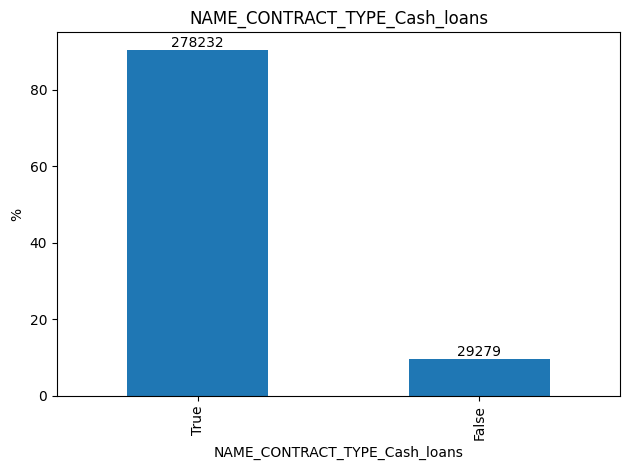

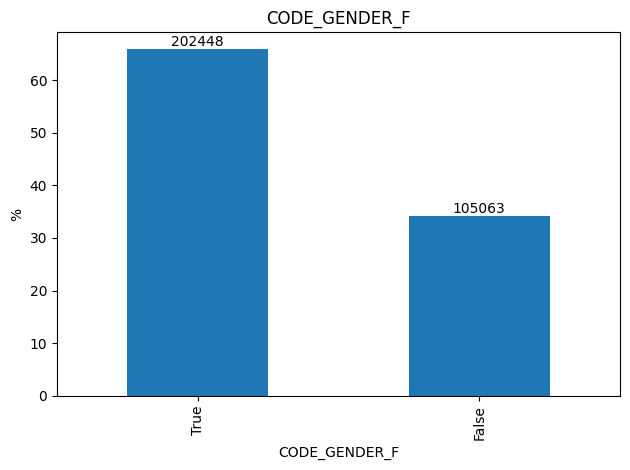

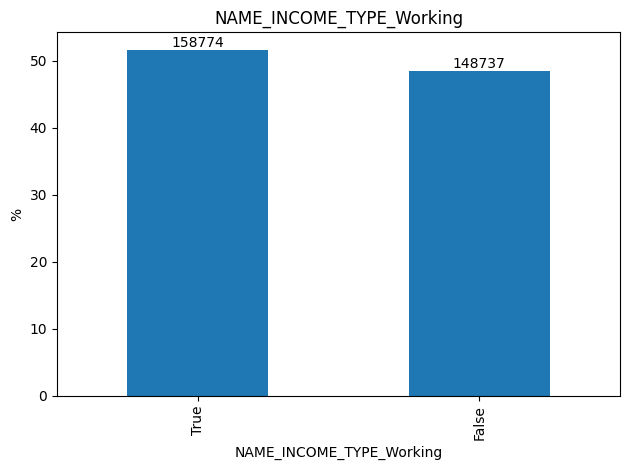

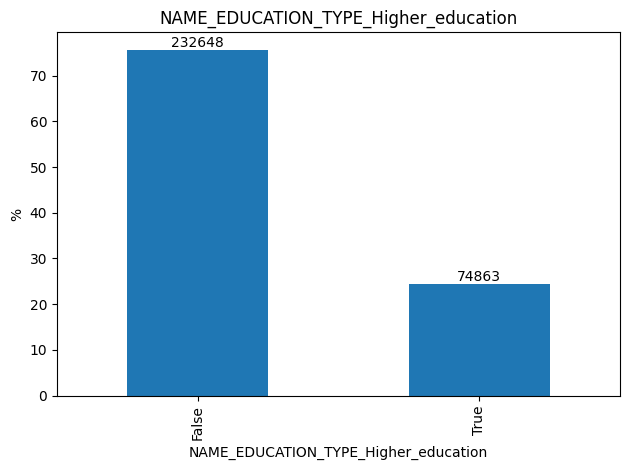

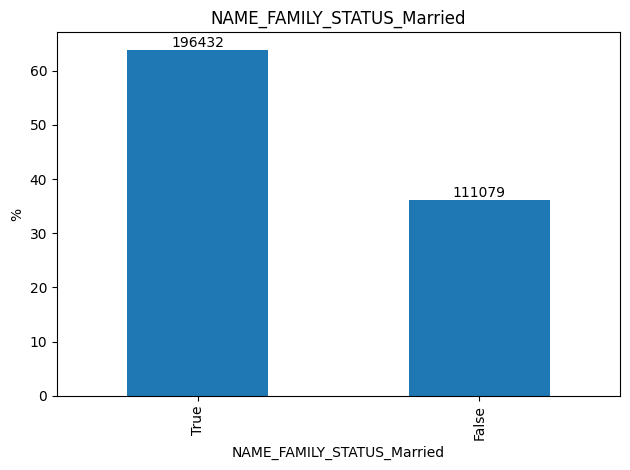

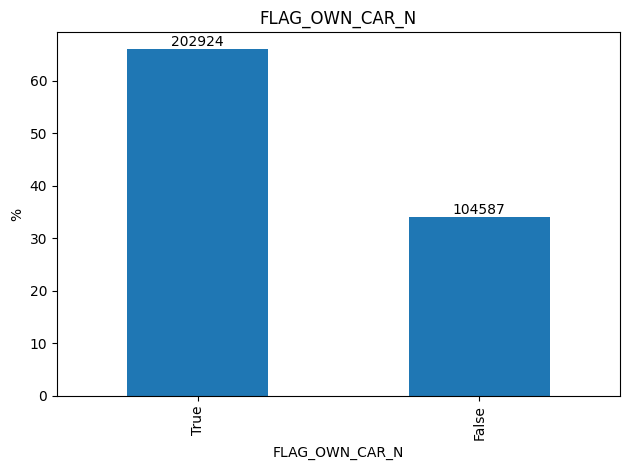

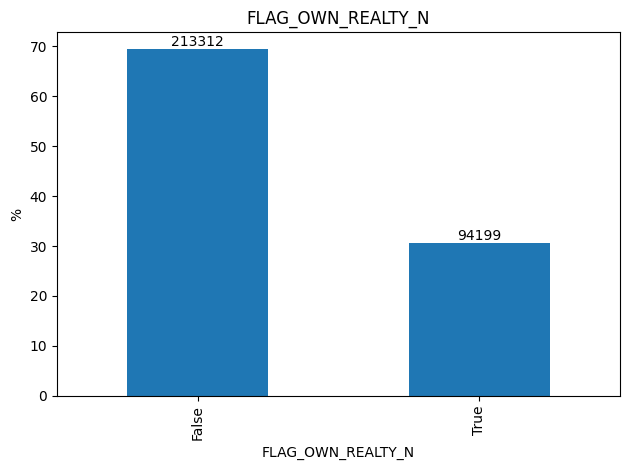


------------------------------------------------------------
BOXPLOTS
------------------------------------------------------------


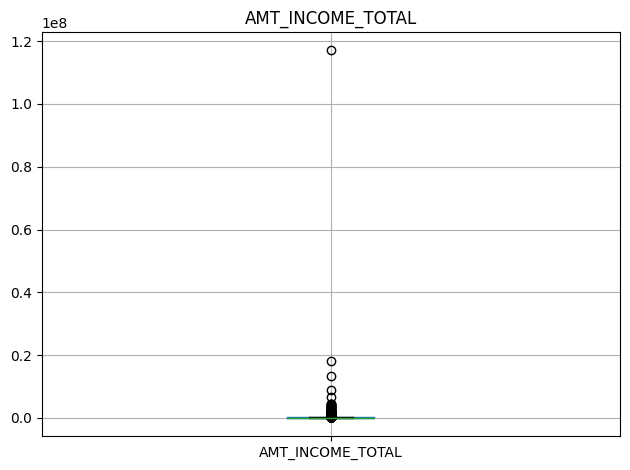

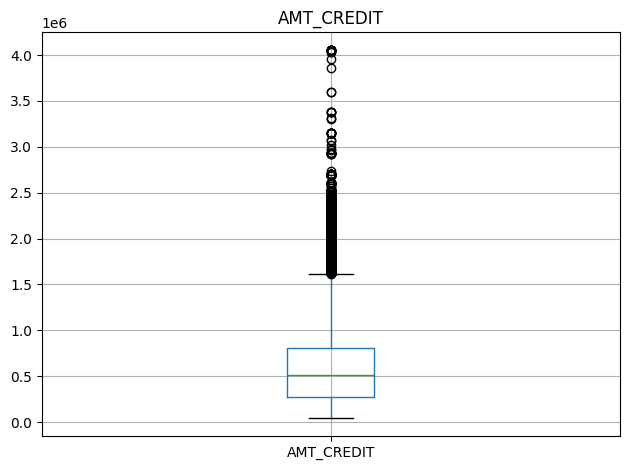

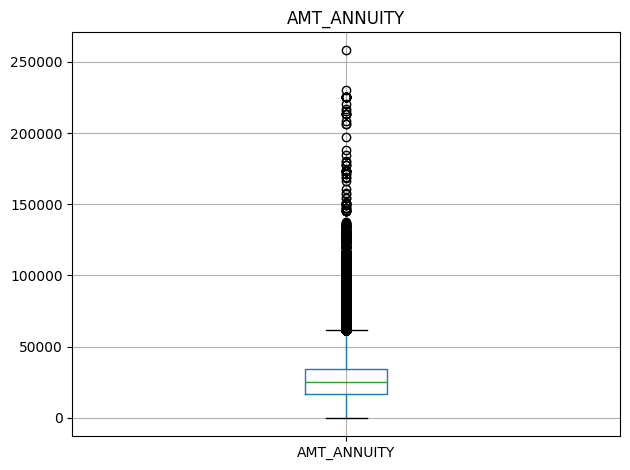

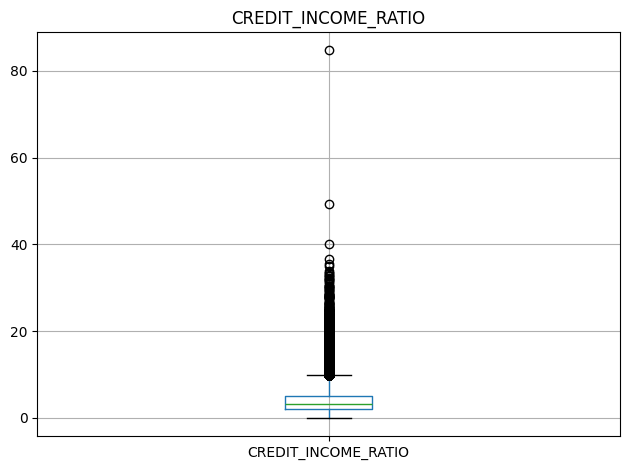

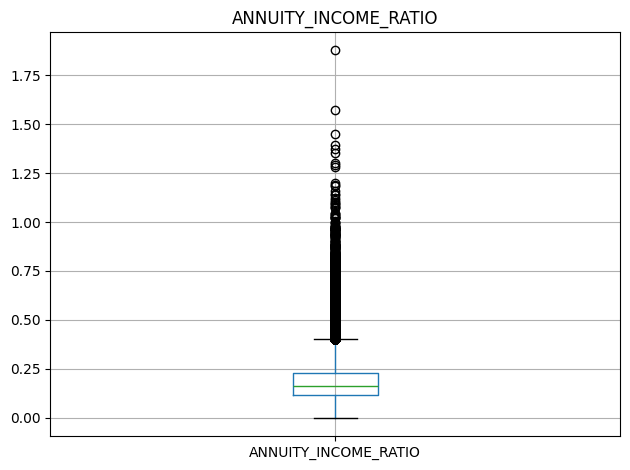

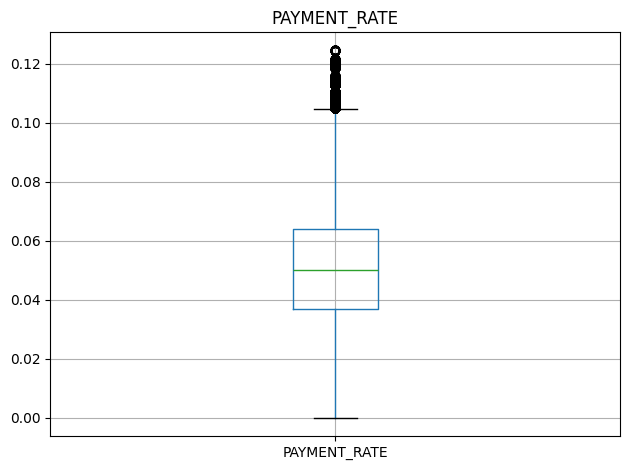

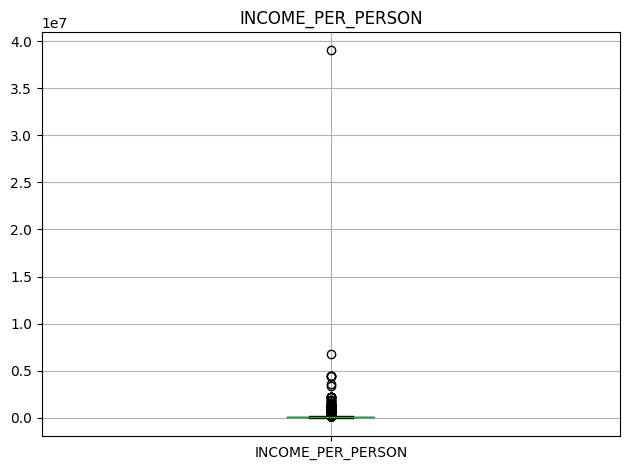

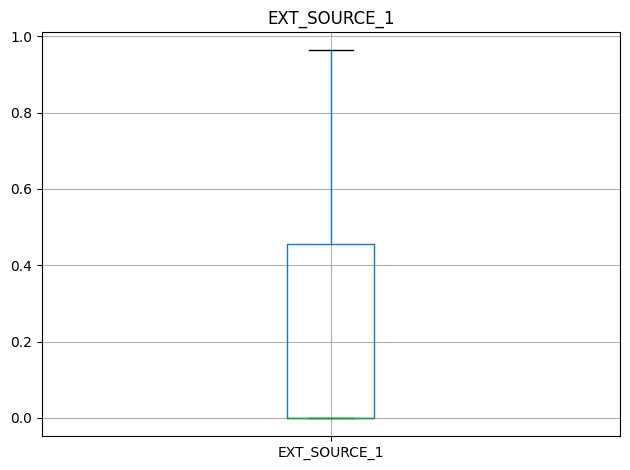

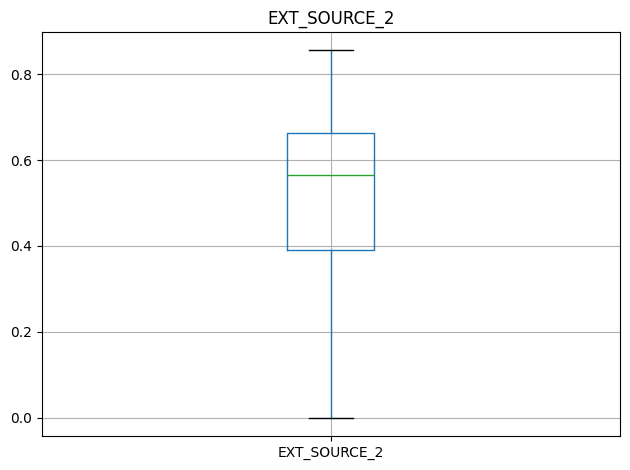

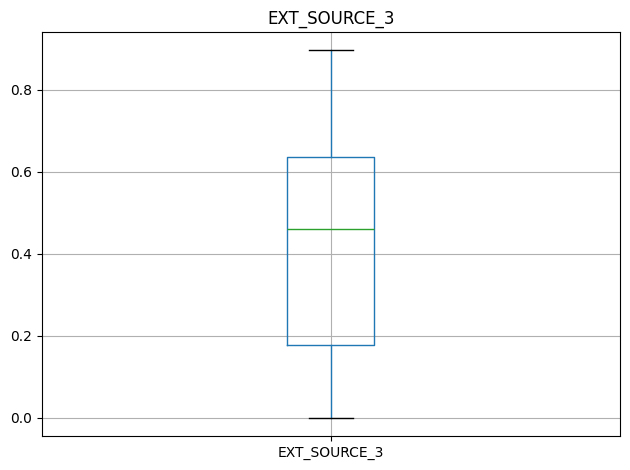

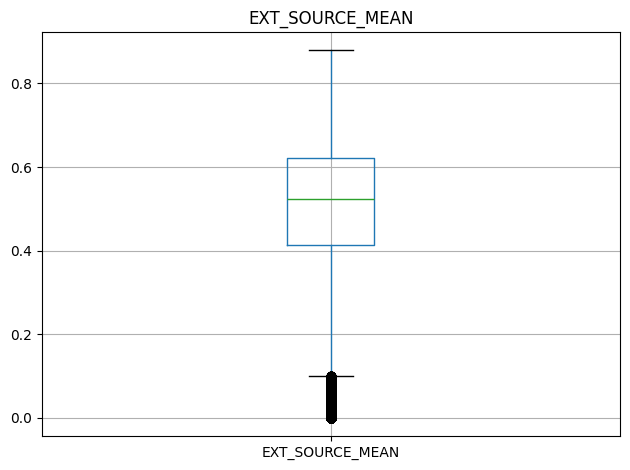

In [38]:
eda(
    X_clean,
    name="X_clean_business",

    show_general=True,
    show_quality=True,
    show_numerical=True,
    show_categorical=False,

    show_barplots=True,
    barplot_cols=[
        "NAME_CONTRACT_TYPE_Cash_loans",
        "CODE_GENDER_F",
        "NAME_INCOME_TYPE_Working",
        "NAME_EDUCATION_TYPE_Higher_education",
        "NAME_FAMILY_STATUS_Married",
        "FLAG_OWN_CAR_N",
        "FLAG_OWN_REALTY_N"
    ],

    show_boxplots=True,
    boxplot_cols=[
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "CREDIT_INCOME_RATIO",
        "ANNUITY_INCOME_RATIO",
        "PAYMENT_RATE",
        "INCOME_PER_PERSON",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
        "EXT_SOURCE_MEAN"
    ]
)


EDA : X_CLEAN_ENGINEERED

------------------------------------------------------------
BOXPLOTS
------------------------------------------------------------


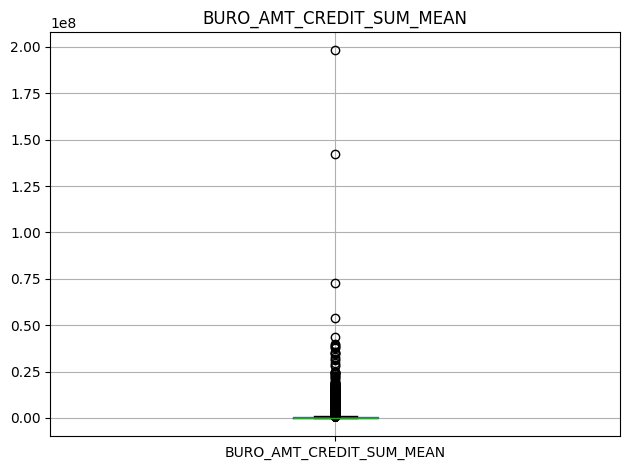

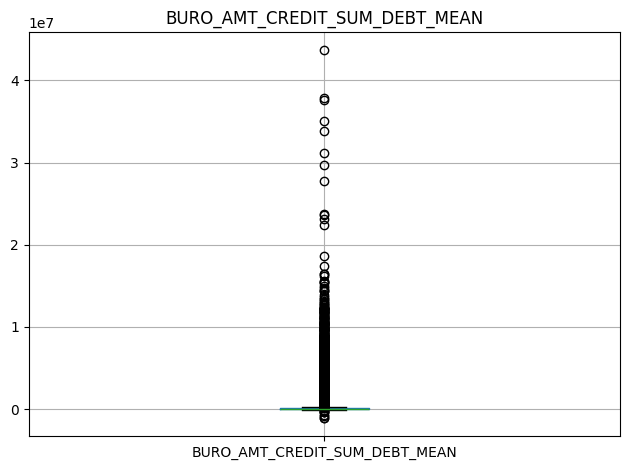

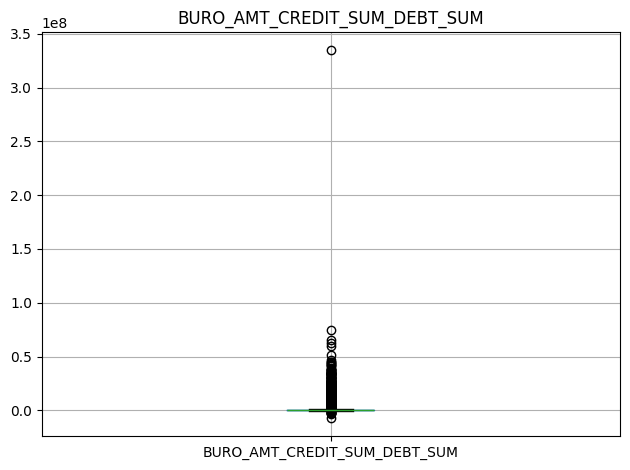

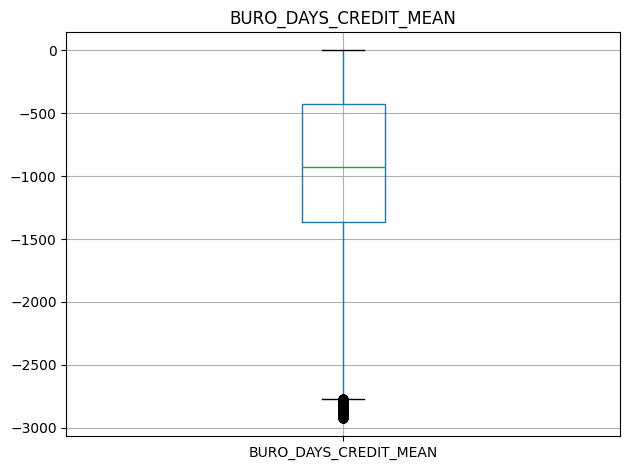

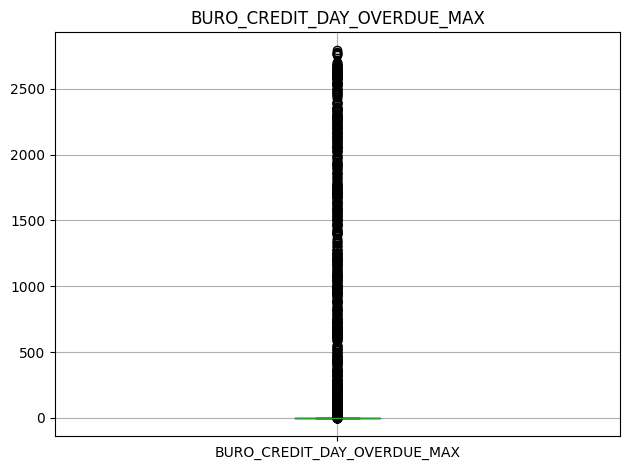

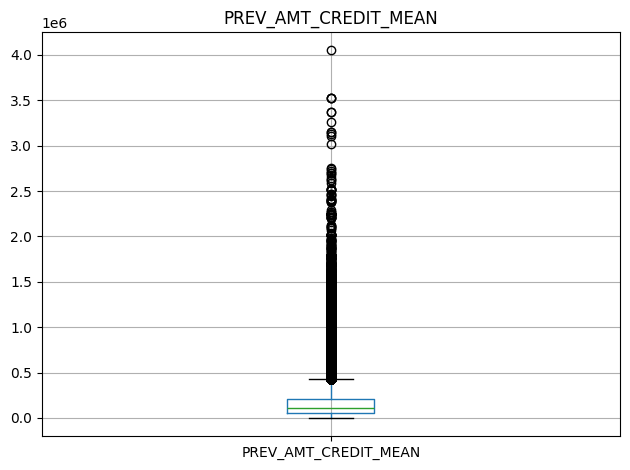

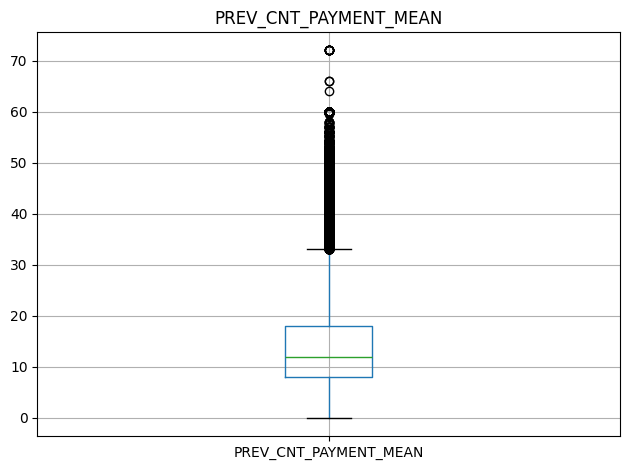

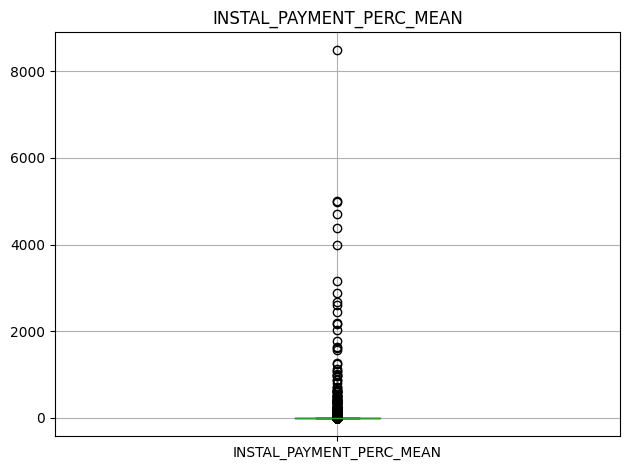

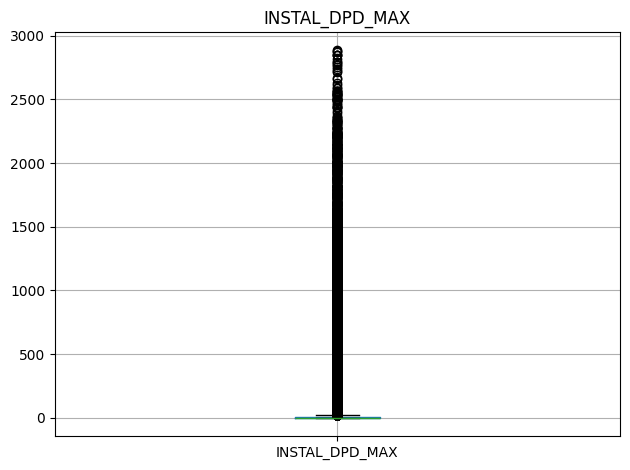

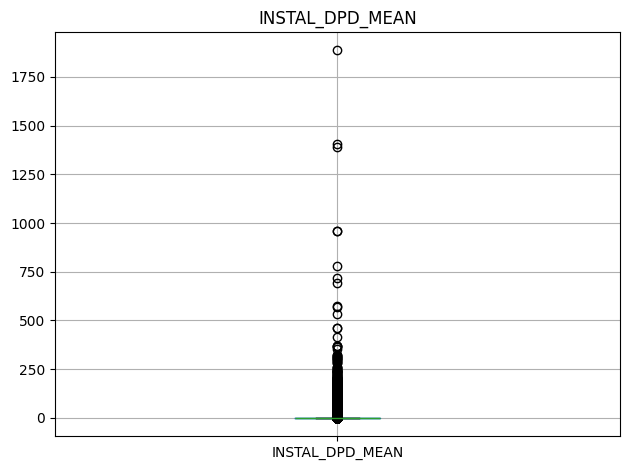

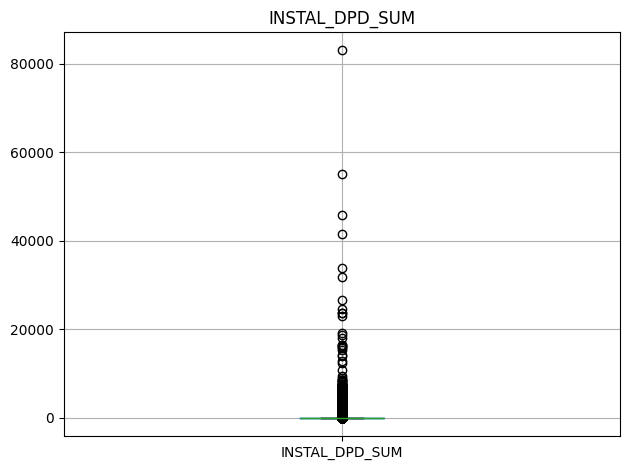

In [39]:
eda(
    X_clean,
    name="X_clean_engineered",

    show_general=False,
    show_quality=False,
    show_numerical=False,
    show_categorical=False,

    show_barplots=False,

    show_boxplots=True,
    boxplot_cols=[
        "BURO_AMT_CREDIT_SUM_MEAN",
        "BURO_AMT_CREDIT_SUM_DEBT_MEAN",
        "BURO_AMT_CREDIT_SUM_DEBT_SUM",
        "BURO_DAYS_CREDIT_MEAN",
        "BURO_CREDIT_DAY_OVERDUE_MAX",
        "PREV_AMT_CREDIT_MEAN",
        "PREV_CNT_PAYMENT_MEAN",
        "INSTAL_PAYMENT_PERC_MEAN",
        "INSTAL_DPD_MAX",
        "INSTAL_DPD_MEAN",
        "INSTAL_DPD_SUM"
    ]
)

#### Structure générale du dataset

Le dataset final utilisé pour la modélisation contient **307 511 observations** et **246 variables explicatives**.

Il est construit à partir de la table principale `application_train`, enrichie par des opérations de feature engineering et par l'intégration d'informations provenant des tables historiques du projet Home Credit.

La variable cible (`TARGET`) ainsi que l'identifiant client (`SK_ID_CURR`) ont été exclus du jeu de variables explicatives.

Les variables conservées appartiennent à plusieurs catégories :

* variables socio-économiques initiales ;
* variables financières brutes ;
* variables dérivées créées lors du feature engineering ;
* variables comportementales issues des historiques de crédit ;
* variables binaires issues du one-hot encoding ;
* variables agrégées construites à partir des tables annexes.

### Feature engineering réalisé

Plusieurs transformations ont été appliquées afin d'enrichir le signal disponible pour la prédiction du risque de défaut.

#### Transformation des variables temporelles

La variable `DAYS_EMPLOYED` contient une anomalie documentée dans le dataset Home Credit :

* la valeur `365243` correspond à une valeur aberrante utilisée comme code technique.

Cette anomalie a été traitée par :

* la création d'un indicateur binaire `DAYS_EMPLOYED_ANOM` ;
* le remplacement de la valeur aberrante par `NaN`.

Des variables plus interprétables ont également été créées :

* `AGE`
* `YEARS_EMPLOYED`

#### Création de ratios financiers

Quatre indicateurs financiers ont été ajoutés :

* `CREDIT_INCOME_RATIO`
* `ANNUITY_INCOME_RATIO`
* `PAYMENT_RATE`
* `INCOME_PER_PERSON`

Ces ratios visent à mieux représenter la solvabilité et la capacité de remboursement des clients.

#### Création d'un score externe synthétique

Les scores externes disponibles dans :

* `EXT_SOURCE_1`
* `EXT_SOURCE_2`
* `EXT_SOURCE_3`

ont été combinés afin de construire :

* `EXT_SOURCE_MEAN`

Cette variable synthétique permet de résumer l'information issue de ces trois indicateurs fortement prédictifs.

#### Encodage des variables catégorielles

Les variables catégorielles ont été transformées par **one-hot encoding**.

Cette étape a entraîné :

* la disparition des colonnes catégorielles d'origine ;
* la création de nombreuses variables binaires ;
* une augmentation importante de la dimensionnalité du dataset.

#### Agrégations multi-tables

Des variables comportementales ont été créées à partir des historiques disponibles.

##### Historique bureau (`bureau`)

Création des variables :

* `BURO_AMT_CREDIT_SUM_*`
* `BURO_AMT_CREDIT_SUM_DEBT_*`
* `BURO_DAYS_CREDIT_*`
* `BURO_CREDIT_DAY_OVERDUE_*`

Ces indicateurs décrivent :

* le volume de crédit détenu ;
* le niveau d'endettement ;
* l'ancienneté de l'historique bancaire ;
* les retards enregistrés.

##### Historique des demandes (`previous_application`)

Création des variables :

* `PREV_AMT_APPLICATION_MEAN`
* `PREV_AMT_CREDIT_MEAN`
* `PREV_APP_CREDIT_PERC_MEAN`
* `PREV_CNT_PAYMENT_MEAN`

Ces variables permettent de caractériser le comportement historique du client lors de précédentes demandes de crédit.

##### Historique des remboursements (`installments_payments`)

Création des variables :

* `INSTAL_PAYMENT_PERC_MEAN`
* `INSTAL_DPD_MAX`
* `INSTAL_DPD_MEAN`
* `INSTAL_DPD_SUM`

Ces variables capturent directement le comportement de remboursement et les retards observés dans le passé.

### Préparation des données pour la modélisation

Une phase de nettoyage supplémentaire a été réalisée avant l'entraînement des modèles.

Les étapes appliquées sont les suivantes :

#### Gestion des valeurs infinies

Les valeurs :

* `+inf`
* `-inf`

ont été remplacées par des valeurs manquantes.

#### Gestion des valeurs manquantes

Les valeurs manquantes ont été remplacées par :

```python
0
```

afin de produire un dataset entièrement exploitable par les modèles.

Après traitement :

* aucune valeur manquante ne subsiste dans `X_clean`.

#### Suppression des colonnes constantes

Les variables ne présentant aucune variabilité ont été supprimées.

Résultat :

* **10 colonnes constantes supprimées**

#### Réduction de la redondance

Une matrice de corrélation a été calculée sur les variables restantes.

Les variables présentant une corrélation absolue supérieure à :

```python
0.99
```

ont été supprimées.

Résultat :

* **28 colonnes supprimées**

Cette étape permet :

* de réduire la redondance ;
* d'alléger la modélisation ;
* d'améliorer l'interprétabilité.

### Analyse des variables

#### Variables financières

Les variables financières restent parmi les plus riches du dataset :

* `AMT_INCOME_TOTAL`
* `AMT_CREDIT`
* `AMT_ANNUITY`
* `AMT_GOODS_PRICE`

Les boxplots montrent :

* une forte dispersion des montants ;
* la présence d'outliers importants ;
* des comportements très hétérogènes entre les clients.

#### Ratios financiers

Les variables créées :

* `CREDIT_INCOME_RATIO`
* `ANNUITY_INCOME_RATIO`
* `PAYMENT_RATE`
* `INCOME_PER_PERSON`

apportent une vision plus pertinente du risque financier que les montants bruts seuls.

#### Scores externes

Les variables :

* `EXT_SOURCE_1`
* `EXT_SOURCE_2`
* `EXT_SOURCE_3`
* `EXT_SOURCE_MEAN`

constituent des indicateurs synthétiques de risque et sont reconnues comme particulièrement prédictives dans le jeu de données Home Credit.

#### Variables comportementales

Les variables :

* `INSTAL_DPD_MAX`
* `INSTAL_DPD_MEAN`
* `INSTAL_DPD_SUM`
* `INSTAL_PAYMENT_PERC_MEAN`

capturent directement les comportements passés de remboursement.

Elles constituent des signaux métier particulièrement pertinents pour l'évaluation du risque de défaut.

### Variables binaires issues de l'encodage

Après one-hot encoding, une part importante du dataset est composée de variables binaires :

* type de contrat ;
* situation familiale ;
* niveau d'éducation ;
* catégorie professionnelle ;
* organisation employeur ;
* conditions de logement.

Ces variables permettent aux modèles de prendre en compte de nombreuses caractéristiques qualitatives.

### Points de vigilance

Plusieurs éléments restent à surveiller :

* présence d'outliers importants dans les variables financières ;
* forte proportion de variables binaires ;
* distributions très asymétriques sur certaines variables métier ;
* risque de surapprentissage lié à la dimension du dataset ;
* importance potentielle de certaines variables fortement corrélées malgré le filtrage effectué.

### Conclusion

Le dataset final est passé de **284 variables initiales** à **246 variables explicatives nettoyées et préparées pour la modélisation**.

Les transformations réalisées ont permis :

* d'enrichir les données avec des indicateurs métier pertinents ;
* d'intégrer des historiques de crédit multi-sources ;
* de supprimer les variables constantes ;
* de réduire les redondances ;
* d'obtenir un dataset sans valeur manquante.

Le jeu de données combine désormais :

* informations socio-économiques ;
* indicateurs financiers ;
* historiques de crédit ;
* comportements de remboursement ;
* variables dérivées à forte valeur métier.

Cette base constitue un socle adapté pour la comparaison des modèles de scoring et le déploiement ultérieur du modèle retenu via MLflow et une API de prédiction.

In [20]:
# SAVE
X_clean.to_parquet(os.path.join(PROCESSED_PATH, "X_clean.parquet"))
y.to_frame().to_parquet(os.path.join(PROCESSED_PATH, "y.parquet"))

### **3.3. LOAD**

In [21]:
# LOAD
X_clean = pd.read_parquet(os.path.join(PROCESSED_PATH, "X_clean.parquet"))

# Le parquet est relu comme un DataFrame à une colonne.
# squeeze() reconvertit automatiquement en Series, ce qui est le format attendu par scikit-learn et les fonctions métier.
y = pd.read_parquet(os.path.join(PROCESSED_PATH, "y.parquet")).squeeze()

## **4. MODELING**

### **4.1. Fonctions génériques**

#### **4.1.1. Metrics business**

In [22]:
def compute_business_cost(
    y_true,
    y_pred,
    y_proba,
    loan_amount,
    fn_weight=10,
    fp_weight=1
):
    """
    Calcule un coût métier pondéré par l'exposition financière.

    Objectif :
    - prendre en compte le montant réel des crédits
    - conserver l'information probabiliste du modèle
    - pénaliser davantage les faux négatifs
    - produire une métrique comparable entre datasets

    Paramètres :
    - y_true : valeurs réelles (0/1)
    - y_pred : prédictions binaires (0/1)
    - y_proba : probabilités de défaut prédites
    - loan_amount : montant des crédits (AMT_CREDIT)
    - fn_weight : poids métier des faux négatifs
    - fp_weight : poids métier des faux positifs

    Principe :
    - Faux négatif (FN) : client risqué accepté
    - Faux positif (FP) : client solvable refusé

    Chaque erreur est pondérée par :
        montant du crédit
        × probabilité de défaut
        × poids métier

    Retour :
    - business_cost_eur : coût métier pondéré en euros
    - business_cost_ratio : coût métier rapporté au portefeuille total

    Interprétation :
    - business_cost_eur : montant financier estimé impacté
    - business_cost_ratio : proportion du portefeuille concernée par les erreurs du modèle
    → plus ces valeurs sont faibles, meilleur est le modèle
    """

    # Conversion en tableaux NumPy 1D: évite les problèmes de format (Series, DataFrame, ndarray).
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    y_proba = np.asarray(y_proba).ravel()
    loan_amount = np.asarray(loan_amount).ravel()

    # Identification des erreurs métier.
    fn_mask = (y_true == 1) & (y_pred == 0) # FN : risque non détecté
    fp_mask = (y_true == 0) & (y_pred == 1)  # FP : client solvable refusé

    # Coût des faux négatifs : pondération forte car impact financier élevé.
    fn_cost = np.sum(
        loan_amount[fn_mask]
        * y_proba[fn_mask]
        * fn_weight
    )

    # Coût des faux positifs : pondération plus faible car perte d'opportunité.
    fp_cost = np.sum(
        loan_amount[fp_mask]
        * y_proba[fp_mask]
        * fp_weight
    )

    # Coût métier global du portefeuille.
    business_cost_eur = fn_cost + fp_cost

    # Encours total étudié : utilisé pour obtenir une métrique comparable entre plusieurs jeux de données ou modèles.
    total_exposure = np.sum(loan_amount)

    # Coût relatif au portefeuille : plus robuste que le coût brut pour comparer plusieurs expérimentations.
    business_cost_ratio = (
        business_cost_eur / total_exposure
        if total_exposure > 0
        else 0
    )

    return business_cost_eur, business_cost_ratio

In [23]:
def optimize_threshold(y_true, y_proba, loan_amount, fn_weight=10, fp_weight=1, n_thresholds=100):
    """
    Trouve le seuil optimal minimisant le coût métier.

    Paramètres :
    - y_true : valeurs réelles
    - y_proba : probabilités du modèle
    - loan_amount : montant des crédits (AMT_CREDIT)
    - fn_weight : coût FN (important métier)
    - fp_weight : coût FP
    - n_thresholds : nombre de seuils testés (précision vs temps)

    Retour :
    - best_threshold (float) : seuil optimal pour le modèle, minimisant le coût métier
    - best_cost_eur (float) : coût métier minimum atteint parmi tous les seuils testés
    - best_cost_ratio (float) : coût métier normalisé minimum atteint parmi tous les seuils testés
        → permet de comparer plusieurs modèles
        → indépendant de la taille de l'échantillon

    - results_df (DataFrame) : tableau contenant :
        - tous les seuils testés
        - le coût métier en euros
        - le coût métier normalisé
        → permet d'analyser la sensibilité du coût au seuil
        → utile pour visualisation (courbe seuil vs coût)
    """

    # On teste plusieurs seuils entre 0 et 1
    # → permet de remplacer le seuil par défaut (0.5)
    thresholds = np.linspace(0, 1, n_thresholds)

    results = []

    for threshold in thresholds:

        # Transformation des probabilités en classes
        # → dépend du seuil testé
        y_pred = (y_proba > threshold).astype(int)

        # Calcul du coût métier pour ce seuil
        cost_eur, cost_ratio = compute_business_cost(
            y_true=y_true,
            y_pred=y_pred,
            y_proba=y_proba,
            loan_amount=loan_amount,
            fn_weight=fn_weight,
            fp_weight=fp_weight
        )

        # Stockage pour analyse et comparaison
        results.append({
            "threshold": threshold,
            "business_cost_eur": cost_eur,
            "business_cost_ratio": cost_ratio
        })

    # Conversion en DataFrame
    # → utile pour analyse graphique
    results_df = pd.DataFrame(results)

    # Sélection du seuil minimisant le coût métier normalisé
    # → plus robuste que le coût brut car indépendant du volume de crédit analysé
    best_row = results_df.loc[
        results_df["business_cost_ratio"].idxmin()
    ]

    best_threshold = best_row["threshold"]
    best_cost_eur = best_row["business_cost_eur"]
    best_cost_ratio = best_row["business_cost_ratio"]

    return (
        best_threshold,
        best_cost_eur,
        best_cost_ratio,
        results_df
    )

#### **4.1.2. Pipeline d’entraînement**

In [24]:
def split_data(X, y, test_size=0.2, random_state=42):
    """
    Sépare les données en train / validation.

    Objectif :
    - entraîner sur une partie des données
    - évaluer sur une autre (généralisation du modèle)

    Choix techniques :
    - stratify=y : conserve la proportion de la classe minoritaire (~8%)
    - test_size=0.2 : compromis classique (80% train / 20% validation)
    - random_state : reproductibilité

    Choix métier :
    - dataset déséquilibré → il est crucial de garder la même distribution

    Retour :
    - X_train : DataFrames des variables explicatives pour l'entraînement
    - X_val : DataFrames des variables explicatives pour la validation
    - y_train : Series de la variable cible pour l'entraînement
    - y_val : Series de la variable cible pour la validation

    → Les données sont séparées de façon aléatoire mais stratifiée,
      ce qui garantit que la proportion des classes (ex : défaut / non défaut)
      est similaire entre train et validation.

    → Les tailles dépendent de test_size :
      - train : (1 - test_size)
      - validation : test_size
    """

    return train_test_split(
        X,                        # données d'entrée (features)
        y,                        # variable cible à prédire
        stratify=y,               # conserve la proportion des classes
        test_size=test_size,      # taille du jeu de validation (ex : 20%)
        random_state=random_state # garantit un split reproductible
    )

In [25]:
def scale_data(X_train, X_val):
    """
    Standardise les variables (centrage + réduction).

    Objectif :
    - rendre les variables comparables (même échelle)
    - améliorer la stabilité et la performance des modèles sensibles aux échelles

    Choix techniques :
    - StandardScaler → transforme chaque variable : moyenne = 0, écart-type = 1
    - fit uniquement sur X_train → calcule moyenne et écart-type sur le train seulement
    - transform sur X_val → applique les mêmes paramètres sans recalcul (évite le data leakage)
    - reconstruction en DataFrame → conservation des noms de colonnes et des index

    Choix métier :
    - aucun direct → transformation purement technique
    - impact indirect : améliore la qualité du modèle donc la décision métier

    Retour :
    - X_train_scaled : DataFrame des variables d'entraînement standardisées avec noms de colonnes conservés
    - X_val_scaled : DataFrame des variables de validation standardisées avec les mêmes paramètres que le train
    """

    scaler = StandardScaler()                       # initialise l'objet de normalisation (apprendra moyenne et écart-type)
    X_train_scaled = scaler.fit_transform(X_train)  # apprend les statistiques sur X_train puis applique la transformation
    X_val_scaled = scaler.transform(X_val)          # applique la transformation sur X_val avec les mêmes paramètres (pas de fit)

    X_train_scaled = pd.DataFrame(                  # reconstruit un DataFrame pour garder noms de colonnes et index
        X_train_scaled,
        columns=X_train.columns,
        index=X_train.index
    )

    X_val_scaled = pd.DataFrame(                    # même reconstruction pour cohérence avec le train
        X_val_scaled,
        columns=X_val.columns,
        index=X_val.index
    )

    return X_train_scaled, X_val_scaled

In [26]:
def train_model_cv(model, param_grid, X_train, y_train):
    """
    Entraîne un modèle avec validation croisée et sélection automatique
    des meilleurs hyperparamètres.

    Objectif :
    - apprendre plusieurs versions du modèle avec différentes configurations
    - identifier celle qui généralise le mieux
    - retourner un modèle déjà entraîné et optimisé

    Choix techniques :
    - StratifiedKFold → conserve la proportion de défauts dans chaque fold
    - validation croisée à 5 folds → évaluation plus robuste qu'un simple split
    - GridSearchCV → teste toutes les combinaisons d'hyperparamètres
    - scoring="roc_auc" → comparaison basée sur la capacité à classer les clients
      du plus risqué au moins risqué
    - n_jobs=2 → limite les risques de saturation mémoire tout en conservant
      un parallélisme utile

    Choix métier :
    - l'objectif ici est uniquement de trouver le meilleur modèle technique
    - le coût métier n'est pas encore pris en compte car il dépend du seuil
    - l'optimisation métier sera réalisée après obtention des probabilités

    Retour :
    - best_model : meilleur modèle entraîné sur l'ensemble du train
    - best_params : hyperparamètres ayant obtenu la meilleure AUC
    """

    cv = StratifiedKFold(
        n_splits=5,             # découpe les données en 5 folds pour la validation croisée
        shuffle=True,           # mélange les données avant découpage pour éviter un biais d'ordre
        random_state=42         # garantit la reproductibilité des splits
    )

    grid = GridSearchCV(
        estimator=model,        # modèle à entraîner et optimiser
        param_grid=param_grid,  # grille des hyperparamètres à tester
        scoring="roc_auc",      # métrique utilisée pour comparer les modèles (indépendante du seuil)
        cv=cv,                  # stratégie de validation croisée définie ci-dessus
        n_jobs=2,               # limite les risques de saturation mémoire
        verbose=1               # affiche la progression de la recherche
    )

    grid.fit(X_train, y_train)  # entraîne tous les modèles avec validation croisée

    return (
        grid.best_estimator_,
        grid.best_params_
    )

In [27]:
def predict_proba(model, X_val):
    """
    Génère les probabilités de défaut pour chaque client.

    Objectif :
    - estimer le risque de défaut client
    - produire un score exploitable pour l'AUC et les décisions métier

    Choix techniques :
    - predict_proba retourne une probabilité pour chaque classe :
        [P(classe 0), P(classe 1)]
    - seule la probabilité de la classe positive (TARGET=1) est conservée
    - aucune décision n'est encore prise à ce stade

    Choix métier :
    - la probabilité permet d'évaluer finement le risque client
    - la décision d'accepter ou refuser sera prise plus tard via un seuil

    Retour :
    - tableau de probabilités de défaut compris entre 0 et 1
    - une valeur par client :
        0   → risque très faible
        1   → risque très élevé
    """

    # Garde uniquement P(TARGET = 1) = probabilité de défaut
    return model.predict_proba(X_val)[:, 1]

In [28]:
def evaluate_auc(y_val, y_proba):
    """
    Calcule l'AUC (Area Under the ROC Curve).

    Objectif :
    - mesurer la capacité du modèle à classer les clients du plus risqué au moins risqué
    - évaluer la qualité des scores de risque produits par le modèle

    Choix techniques :
    - compare les probabilités prédites (y_proba) aux vraies classes (y_val)
    - utilise les probabilités directement, sans transformer en 0/1
    - indépendant de tout seuil de décision
    - adapté aux jeux de données déséquilibrés

    Interprétation :
    L'AUC ne vérifie pas si les probabilités sont exactes, elle vérifie si les clients réellement en défaut reçoivent
    généralement des probabilités plus élevées que les autres, elle mesure donc la qualité du classement des risques

    Exemple :
    y_val   = [0, 1, 0, 1]
    y_proba = [0.10, 0.80, 0.20, 0.90]

    Les clients en défaut reçoivent les scores les plus élevés : classement parfait → AUC = 1.0

    Choix métier :
    - utile pour comparer plusieurs modèles de manière neutre
    - ne représente pas directement le coût financier réel
    - ne permet pas à lui seul de prendre une décision d'acceptation/refus

    Retour :
    - score AUC compris entre 0 et 1

        1.0  → séparation parfaite
        0.5  → modèle aléatoire
        <0.5 → classement inversé

    - plus l'AUC est élevée, plus le modèle distingue correctement les clients risqués des clients non risqués
    """

    return roc_auc_score(y_val, y_proba)    # Compare les probabilités prédites aux vraies classes et mesure la qualité du classement des clients par risque.

In [29]:
def log_mlflow(
    model,
    best_params,
    auc,
    cost_eur,
    cost_ratio,
    threshold,
    threshold_results,
    X,
    scale,
    model_name,
    fn_weight=10,
    fp_weight=1
):
    """
    Enregistre une expérience de machine learning dans MLflow.

    Objectif :
    - conserver un historique complet des expérimentations
    - comparer facilement plusieurs modèles et configurations
    - assurer la traçabilité des résultats
    - sauvegarder le modèle entraîné pour une réutilisation future
      (batch, API, monitoring)

    Choix techniques :
    - journalisation des paramètres d'entraînement
    - journalisation des métriques métier et techniques
    - sauvegarde du modèle comme artefact
    - sauvegarde des variables utilisées
    - sauvegarde des résultats d'optimisation du seuil

    Choix métier :
    - conservation du coût métier
    - conservation du seuil optimal
    - conservation des poids FN / FP
    - reproductibilité complète du modèle

    Retour :
    - aucun
    """

    if RUN_MLFLOW:
        RUN_VERSION = "v1"
        FEATURE_VERSION = "features_v1"
        with mlflow.start_run(
            run_name=f"{model_name}_{FEATURE_VERSION}_{RUN_VERSION}"
        ):

            # Paramètres
            params = {
                "model": model.__class__.__name__,
                "best_params": str(best_params),
                "n_features": X.shape[1],
                "scale": scale,
                "feature_version": FEATURE_VERSION,
                "fn_weight": fn_weight,
                "fp_weight": fp_weight
            }

            for key, value in params.items():
                mlflow.log_param(key, value)

            # Métriques
            metrics = {
                "auc": auc,
                "business_cost_eur": cost_eur,
                "business_cost_ratio": cost_ratio,
                "threshold": threshold
            }
            for key, value in metrics.items():
                mlflow.log_metric(key, value)

            # Features utilisées
            features_file = "features.csv"
            pd.DataFrame({
                "feature": X.columns
            }).to_csv(
                features_file,
                index=False
            )
            mlflow.log_artifact(features_file)

            # Optimisation du seuil
            threshold_file = "threshold_results.csv"
            threshold_results.to_csv(
                threshold_file,
                index=False
            )
            mlflow.log_artifact(threshold_file)

            # Modèle
            if isinstance(model, LGBMClassifier):
                mlflow.lightgbm.log_model(
                    lgb_model=model,
                    name="model",
                    registered_model_name=model_name
                )
            else:
                mlflow.sklearn.log_model(
                    sk_model=model,
                    name="model",
                    registered_model_name=model_name,
                    serialization_format="pickle"
                )

            print(f"Modèle '{model_name}' enregistré dans le Model Registry.")

In [30]:
def run_model(
    model,
    param_grid,
    X,
    y,
    model_name="model",
    scale=False
):
    """
    Exécute le pipeline complet d'entraînement et d'évaluation d'un modèle.

    Objectif :
    - entraîner un modèle de scoring de bout en bout
    - comparer les performances techniques et métier
    - produire un modèle prêt à être enregistré et réutilisé

    Choix techniques :
    - séparation train / validation pour évaluer la généralisation
    - scaling optionnel selon les besoins du modèle
    - validation croisée + recherche d'hyperparamètres
    - évaluation par AUC à partir des probabilités prédites
    - optimisation du seuil pour minimiser le coût métier

    Choix métier :
    - séparation entre qualité du modèle (AUC) et qualité de la décision (coût métier)
    - le coût métier est calculé à partir des montants réels des crédits
    - recherche du seuil le plus rentable
    - traçabilité complète via MLflow

    Point d'attention :
    - certains modèles nécessitent une standardisation des variables (ex : LogisticRegression)
    - AMT_CREDIT est alors transformée par le StandardScaler
    - le coût métier doit néanmoins être calculé avec les montants réels des crédits et non les valeurs standardisées
    - les montants sont donc sauvegardés avant le scaling puis réutilisés dans l'optimisation métier

    Retour :
    - results : dictionnaire standardisé contenant :
        * modèle entraîné
        * AUC
        * coût métier en euros
        * coût métier normalisé
        * seuil optimal
        * hyperparamètres optimaux
        * données nécessaires aux analyses

    - optimized_model : meilleur modèle entraîné
    """

    # 1. Séparation train / validation
    X_train, X_val, y_train, y_val = split_data(X, y)

    # Conservation des montants réels des crédits.
    # Cette copie est réalisée avant le scaling afin de calculer les coûts métier sur les véritables montants accordés.
    # Sans cela, AMT_CREDIT serait standardisée pour certains modèles et le calcul financier deviendrait incohérent.
    loan_amount_val = X_val["AMT_CREDIT"].copy()

    # 2. Standardisation optionnelle
    # Utile pour les modèles linéaires mais généralement inutile pour les modèles d'arbres comme LightGBM.
    if scale:
        X_train, X_val = scale_data(
            X_train,
            X_val)

    # 3. Recherche des meilleurs hyperparamètres par CV
    optimized_model, best_params = train_model_cv(
        model,
        param_grid,
        X_train,
        y_train)

    # 4. Prédiction des probabilités de défaut
    y_proba = predict_proba(
        optimized_model,
        X_val)

    # 5. Évaluation de la qualité du classement des clients
    auc = evaluate_auc(
        y_val,
        y_proba)

    # 6. Recherche du seuil minimisant le coût métier.
    # Le coût tient compte :
    # - du type d'erreur (FN ou FP)
    # - de la probabilité de défaut
    # - du montant réel du crédit accordé
    (
        threshold,
        cost_eur,
        cost_ratio,
        threshold_results
    ) = optimize_threshold(
        y_true=y_val,
        y_proba=y_proba,
        loan_amount=loan_amount_val
    )

    # 7. Sauvegarde de l'expérience dans MLflow
    log_mlflow(
        optimized_model,
        best_params,
        auc,
        cost_eur,
        cost_ratio,
        threshold,
        threshold_results,
        X,
        scale,
        model_name)

    # 8. Résultats conservés pour les analyses futures
    results = {
        "model": model_name,
        "auc": auc,
        "business_cost_eur": cost_eur,
        "business_cost_ratio": cost_ratio,
        "threshold": threshold,
        "best_params": best_params,

        # Données de validation
        "X_val": X_val,
        "y_val": y_val,
        "y_proba": y_proba,

        # Montants réels des crédits utilisés pour les calculs métier ultérieurs
        "loan_amount": loan_amount_val,

        # Historique complet de l'optimisation du seuil
        "threshold_results": threshold_results
    }

    # Résumé synthétique
    print({
        "model": model_name,
        "auc": auc,
        "business_cost_eur": cost_eur,
        "business_cost_ratio": cost_ratio,
        "threshold": threshold,
        "best_params": best_params
    })

    return results, optimized_model

#### **4.1.3. Analyses**

In [31]:
def global_feature_importance(model, X, top_n=20):
    """
    Analyse l'importance globale des variables.

    Objectif :
    - identifier les variables les plus influentes dans le modèle
    - comprendre les drivers principaux du risque

    Choix techniques :
    - utilisation de feature_importances_ (modèles arbres)
    - tri décroissant pour visualisation

    Limite :
    - ne donne pas le sens (positif/négatif)
    - dépend du type de modèle

    Choix métier :
    - permet d’identifier les facteurs de risque principaux
    - utile pour interprétation globale et présentation
    """

    # Récupération des importances
    importances = model.feature_importances_

    # Création DataFrame
    fi_df = pd.DataFrame({
        "feature": X.columns,
        "importance": importances
    })

    # Tri décroissant
    fi_df = fi_df.sort_values("importance", ascending=False)

    # Affichage top variables
    print(fi_df.head(top_n))

    # Visualisation
    fi_df.head(top_n).plot.barh(
        x="feature",
        y="importance",
        figsize=(8, 6)
    )

    return fi_df

In [32]:
def local_feature_analysis(
    model,
    X,
    y_proba,
    top_n=15,
    n_random=3,
    random_state=42
):
    """
    Réalise une analyse locale de plusieurs prédictions à l'aide de SHAP.

    Objectif :
    - comprendre pourquoi le modèle attribue certains scores de risque
    - identifier les variables qui augmentent ou réduisent le risque
    - comparer différents profils représentatifs de la population
    - fournir une explicabilité locale exploitable en soutenance

    Choix techniques :
    - utilisation prioritaire de SHAP pour obtenir une explicabilité locale
    - sélection automatique de l'explainer adapté au modèle :
        * TreeExplainer pour les modèles d'arbres
        * LinearExplainer pour les modèles linéaires
        * Explainer générique pour les autres modèles
    - limitation du nombre de variables affichées pour améliorer la lisibilité
    - calcul SHAP uniquement sur les profils étudiés afin de réduire e temps de calcul

    Choix métier :
    - facilite la justification d'une décision de crédit
    - améliore la transparence du modèle
    - met en évidence les facteurs de risque individuels
    - fournit des exemples concrets pour les parties prenantes

    Profils analysés :
    - MIN_RISK : client avec la probabilité la plus faible
    - MAX_RISK : client avec la probabilité la plus élevée
    - MEAN_RISK : client le plus proche de la probabilité moyenne
    - MEDIAN_RISK : client le plus proche de la probabilité médiane
    - RANDOM_1 à RANDOM_n : clients tirés aléatoirement

    Paramètres :
    - model : modèle entraîné
    - X : pandas.DataFrame données utilisées pour les prédictions
    - y_proba : array-like probabilités prédites
    - top_n : int nombre maximal de variables affichées
    - n_random : int nombre de clients aléatoires à analyser
    - random_state : int graine utilisée pour la reproductibilité

    Retour :
    - profiles_results : dict dictionnaire contenant un DataFrame d'analyse pour chaque profil étudié
    """

    # Probabilité prédite pour chaque client
    analysis_df = pd.DataFrame({"proba": y_proba}, index=X.index)

    # Sélection de profils représentatifs
    profiles = {
        "MIN_RISK": analysis_df["proba"].idxmin(),
        "MAX_RISK": analysis_df["proba"].idxmax(),
        "MEAN_RISK": (
            analysis_df["proba"]
            .sub(analysis_df["proba"].mean())
            .abs()
            .idxmin()),
        "MEDIAN_RISK": (
            analysis_df["proba"]
            .sub(analysis_df["proba"].median())
            .abs()
            .idxmin())
    }

    # Ajout de quelques clients tirés aléatoirement
    np.random.seed(random_state)

    profiles.update({
        f"RANDOM_{i}": idx
        for i, idx in enumerate(
            np.random.choice(
                analysis_df.index,
                size=n_random,
                replace=False),
            start=1)
    })

    # Clients nécessitant une explication locale
    clients_to_explain = X.loc[list(profiles.values())]
    shap_available = True
    try:
        print(f"Utilisation de SHAP pour : {model.__class__.__name__}")

        # Référence utilisée par certains explainers SHAP
        background = shap.sample(
            X,
            min(200, len(X)),
            random_state=random_state
        )

        # Sélection automatique de l'explainer adapté
        if hasattr(model, "feature_importances_"):
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(clients_to_explain)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
            explainer_type = "tree"
        elif hasattr(model, "coef_"):
            explainer = shap.LinearExplainer(
                model,
                background)
            shap_values = explainer.shap_values(
                clients_to_explain)
            explainer_type = "linear"
        else:
            explainer = shap.Explainer(
                model,
                background)
            shap_values = explainer(clients_to_explain)
            explainer_type = "generic"
    except Exception as e:
        shap_available = False
        print("\nSHAP indisponible pour ce modèle.")
        print(f"Erreur : {e}")
    profiles_results = {}

    # Analyse de chaque profil sélectionné
    for pos, (profile_name, client_idx) in enumerate(profiles.items()):
        print(
            f"\n{'=' * 80}\n"
            f"PROFIL : {profile_name}\n"
            f"{'=' * 80}")
        print(f"Index client : {client_idx}")
        print(f"Probabilité prédite : {analysis_df.loc[client_idx, 'proba']:.4f}")
        client_data = X.loc[[client_idx]]
        if shap_available:
            try:
                # Contribution des variables pour ce client
                client_shap = shap_values[pos]
                if explainer_type == "generic":
                    shap_array = client_shap.values
                    waterfall_explanation = client_shap
                else:
                    shap_array = client_shap
                    base_value = (
                        explainer.expected_value
                        if explainer_type == "linear"
                        else (
                            explainer.expected_value
                            if np.isscalar(explainer.expected_value)
                            else explainer.expected_value[1])
                    )
                    waterfall_explanation = shap.Explanation(
                        values=shap_array,
                        base_values=base_value,
                        data=client_data.iloc[0].values,
                        feature_names=X.columns.tolist()
                    )

                # Tableau des contributions locales
                local_df = pd.DataFrame({
                    "feature": X.columns,
                    "value": client_data.iloc[0].values,
                    "shap_value": shap_array
                })

                # Variables ayant le plus influencé la prédiction
                local_df["abs_shap"] = local_df["shap_value"].abs()
                local_df = (
                    local_df
                    .sort_values("abs_shap", ascending=False)
                    .head(top_n)
                    .reset_index(drop=True)
                )
                display(local_df)

                # Visualisation de la formation du score
                shap.plots.waterfall(
                    waterfall_explanation,
                    max_display=top_n,
                    show=True
                )
            except Exception as e:
                print(f"Erreur SHAP locale : {e}")
        else:

            # Fallback basé sur les importances globales
            if hasattr(model, "feature_importances_"):
                importance = model.feature_importances_
            elif hasattr(model, "coef_"):
                importance = np.abs(model.coef_[0])
            else:
                print("Aucune importance disponible.")
                continue
            local_df = pd.DataFrame({
                "feature": X.columns,
                "value": client_data.iloc[0].values,
                "importance": importance
            })
            local_df = (
                local_df
                .sort_values("importance", ascending=False)
                .head(top_n)
                .reset_index(drop=True)
            )
            display(local_df)
        profiles_results[profile_name] = local_df

    return profiles_results

In [33]:
def global_model_analysis(
    y_val,
    y_proba,
    loan_amount,
    threshold,
    model_name=None,
    fn_weight=10,
    fp_weight=1
):
    """
    Analyse globale du modèle.

    Objectif :
    - visualiser la distribution des scores de risque
    - analyser les erreurs de classification
    - mesurer l'impact métier du seuil choisi
    - interpréter les performances du modèle dans un contexte de crédit

    Choix techniques :
    - histogramme des probabilités prédites
    - application du seuil métier optimisé
    - matrice de confusion
    - calcul du coût métier à partir des montants de crédit

    Choix métier :
    - les faux négatifs (FN) sont fortement pénalisés : client risqué accepté
    - les faux positifs (FP) sont moins critiques : client solvable refusé
    - chaque erreur est pondérée par le montant du crédit et la probabilité de défaut
    - le seuil retenu doit minimiser le coût métier global

    Retour :
    - metrics_df : DataFrame contenant :
        * coût métier estimé en euros
        * coût métier normalisé
        * métriques de classification
        * matrice de confusion

    - affiche :
        * distribution des scores
        * principaux indicateurs métier
    """

    # Distribution des scores
    plt.figure(figsize=(8, 5))
    plt.hist(y_proba, bins=50)

    plt.axvline(
        threshold,
        color="red",
        linestyle="--",
        label=f"Threshold = {threshold:.3f}"
    )

    plt.title("Distribution des probabilités de défaut")
    plt.xlabel("Probabilité")
    plt.ylabel("Nombre de clients")
    plt.legend()
    plt.show()

    # Transformation des probabilités en décisions
    y_pred = (y_proba > threshold).astype(int)

    # Matrice de confusion
    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    # Calcul du coût métier
    business_cost_eur, business_cost_ratio = (
        compute_business_cost(
            y_true=y_val,
            y_pred=y_pred,
            y_proba=y_proba,
            loan_amount=loan_amount,
            fn_weight=fn_weight,
            fp_weight=fp_weight
        )
    )

    # Construction du tableau d'analyse
    metrics_df = pd.DataFrame({
        "metric": [
            "threshold",
            "business_cost_eur",
            "business_cost_ratio",
            "TN",
            "FP",
            "FN",
            "TP",
            "recall_default",
            "false_positive_rate",
            "precision_default",
            "accuracy"
        ],
        "value": [
            threshold,
            business_cost_eur,
            business_cost_ratio,
            tn,
            fp,
            fn,
            tp,
            tp / (tp + fn),
            fp / (fp + tn),
            tp / (tp + fp),
            (tp + tn) / (tp + tn + fp + fn)
        ]
    })

    # Affichage
    print("\n" + "=" * 60)

    if model_name is not None:
        print("MODÈLE :", model_name)

    print("=" * 60)

    display(metrics_df)

    print(f"\nFN = {fn} (clients risqués acceptés)")
    print(f"FP = {fp} (clients solvables refusés)")
    print(f"Coût métier estimé = {business_cost_eur:,.0f} €")
    print(f"Coût métier normalisé = {business_cost_ratio:.4f}")

    return metrics_df

### **4.2. Modèles**

#### **4.2.1. Baseline : DummyClassifier**

In [34]:
# Hyperparamètres testés
param_grid_dummy = {
    # "prior" : prédit systématiquement selon la proportion observée des classes dans le jeu d'entraînement.
    # Exemple : TARGET = 8% le modèle produira toujours une probabilité ≈ 0.08
    # Sert uniquement de référence minimale.
    "strategy": ["prior"]
}

results_dummy, model_dummy = run_model(
    model=DummyClassifier(
        random_state=42
    ),
    param_grid=param_grid_dummy,
    X=X_clean,
    y=y,
    model_name="DummyClassifier",
    scale=False
)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


2026/07/08 07:26:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modèle 'DummyClassifier' enregistré dans le Model Registry.
{'model': 'DummyClassifier', 'auc': np.float64(0.5), 'business_cost_eur': np.float64(2240520805.4140515), 'business_cost_ratio': np.float64(0.06094154552574148), 'threshold': np.float64(0.08080808080808081), 'best_params': {'strategy': 'prior'}}


Successfully registered model 'DummyClassifier'.
Created version '1' of model 'DummyClassifier'.


#### **4.2.2. Modèle simple : LogisticRegression**

In [35]:
param_grid_logreg = {
    # Intensité de la régularisation.
    # Petit C : modèle plus simple, moins de risque de surapprentissage
    # Grand C : modèle plus flexible risque plus élevé d'overfitting
    # Exploration sur plusieurs ordres de grandeur, pratique classique pour les modèles linéaires.
    "C": [0.01, 0.1, 1, 10],

    # Gestion du déséquilibre de classes, TARGET ≈ 8%.
    # None : poids identiques pour toutes les classes.
    # balanced : sklearn augmente automatiquement le poids de la classe minoritaire.
    # Très pertinent dans un contexte de scoring crédit.
    "class_weight": [None, "balanced"]
}

results_logreg, model_logreg = run_model(
    model=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_grid=param_grid_logreg,
    X=X_clean,
    y=y,
    model_name="LogisticRegression",
    scale=True
)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


2026/07/08 07:30:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modèle 'LogisticRegression' enregistré dans le Model Registry.
{'model': 'LogisticRegression', 'auc': np.float64(0.7520566637943192), 'business_cost_eur': np.float64(9572787563.452244), 'business_cost_ratio': np.float64(0.2603771711008803), 'threshold': np.float64(0.5151515151515152), 'best_params': {'C': 0.1, 'class_weight': 'balanced'}}


Successfully registered model 'LogisticRegression'.
Created version '1' of model 'LogisticRegression'.


#### **4.2.3. Modèle complexe : LGBMClassifier**

In [40]:
param_grid_lgbm = {

    # Nombre d'arbres.
    # Plus il y a d'arbres, plus le modèle peut capturer des relations complexes.
    # Valeurs raisonnables pour une première recherche.
    "n_estimators": [100, 300],

    # Vitesse d'apprentissage.
    # Petite valeur : apprentissage plus lent mais souvent meilleure généralisation.
    # Valeurs classiques pour LightGBM.
    "learning_rate": [0.05, 0.1],

    # Profondeur maximale des arbres.
    # Contrôle la complexité du modèle.
    # Plus la profondeur est grande, plus le risque de surapprentissage augmente.
    "max_depth": [3, 5],

    # Gestion du déséquilibre.
    # Même logique que pour LogisticRegression.
    "class_weight": [None, "balanced"]
}

results_lgbm, model_lgbm = run_model(
    model=LGBMClassifier(
        random_state=42,
        verbosity=-1,
        n_jobs=1
    ),
    param_grid=param_grid_lgbm,
    X=X_clean,
    y=y,
    model_name="LGBMClassifier",
    scale=False
)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Modèle 'LGBMClassifier' enregistré dans le Model Registry.
{'model': 'LGBMClassifier', 'auc': np.float64(0.7770744178081691), 'business_cost_eur': np.float64(1821029412.500013), 'business_cost_ratio': np.float64(0.049531495792146954), 'threshold': np.float64(0.09090909090909091), 'best_params': {'class_weight': None, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}}


Successfully registered model 'LGBMClassifier'.
Created version '1' of model 'LGBMClassifier'.


### **4.3. Meilleur modèle**

#### **Comparaison des modèles**

Trois approches ont été évaluées afin de construire un modèle de scoring capable d'estimer le risque de défaut de paiement :

- un modèle de référence (`DummyClassifier`) ;
- un modèle linéaire interprétable (`LogisticRegression`) ;
- un modèle d'ensemble plus complexe (`LGBMClassifier`).

Performances obtenues :

| Modèle | AUC | Coût métier |
|----------|----------:|----------:|
| DummyClassifier | 0.500 | 49 650 |
| LogisticRegression | 0.752 | 33 314 |
| LGBMClassifier | 0.777 | 30 799 |

##### **Analyse des résultats**

Le `DummyClassifier` constitue uniquement une référence minimale.

Avec une AUC de 0.50, ses performances sont équivalentes à celles d'un tirage aléatoire. Son coût métier est également le plus élevé, ce qui confirme son incapacité à distinguer les clients risqués des clients non risqués.

La `LogisticRegression` apporte une amélioration importante :

- AUC de 0.752 ;
- réduction significative du coût métier ;
- modèle simple et facilement interprétable.

Ce résultat montre que les variables construites lors du feature engineering contiennent un signal prédictif exploitable.

Le `LGBMClassifier` obtient les meilleures performances :

- meilleure AUC ;
- coût métier le plus faible ;
- meilleure capacité à capturer les relations non linéaires entre les variables.

L'écart d'AUC avec la régression logistique reste modéré, mais l'amélioration du coût métier est cohérente avec l'objectif principal du projet : limiter les erreurs financières les plus coûteuses.

##### **Modèle retenu**

Le modèle retenu est le **LGBMClassifier** car il offre le meilleur compromis entre :

- performance prédictive ;
- coût métier ;
- capacité à exploiter la richesse du dataset ;
- compatibilité avec une mise en production via API.

Il sera utilisé pour la suite du projet ainsi que pour le déploiement.

In [41]:
MODEL_NAME = "LGBMClassifier"

MODELS = {
    "DummyClassifier": (results_dummy, model_dummy),
    "LogisticRegression": (results_logreg, model_logreg),
    "LGBMClassifier": (results_lgbm, model_lgbm)
}

BEST_RESULTS, BEST_MODEL = MODELS[MODEL_NAME]
BEST_MODEL_NAME = MODEL_NAME

print("Modèle sélectionné :", BEST_MODEL_NAME)

Modèle sélectionné : LGBMClassifier


In [42]:
# Sauvegarde du modèle retenu.
# Ce fichier sera utilisé pour le déploiement via l'API.
MODELS_PATH = os.path.join(PROJECT_PATH, "models")
os.makedirs(MODELS_PATH, exist_ok=True)
joblib.dump(BEST_MODEL, os.path.join(MODELS_PATH, "best_model.pkl"))

# Sauvegarde de la liste des variables utilisées lors de l'entraînement.
# Permet de garantir la cohérence entre :
# - entraînement
# - API
# - prédictions futures
joblib.dump(X_clean.columns.tolist(),os.path.join(MODELS_PATH, "feature_names.pkl"))

# Sauvegarde du seuil utilisé lors de l'entraînement.
joblib.dump(BEST_RESULTS["threshold"], os.path.join(MODELS_PATH, "threshold.pkl"))

print(f"Modèle sauvegardé : {os.path.join(MODELS_PATH, 'best_model.pkl')}")
print(f"Features sauvegardées : {os.path.join(MODELS_PATH, 'feature_names.pkl')}")
print(f"Seuil sauvegardé : {os.path.join(MODELS_PATH, 'threshold.pkl')}")

Modèle sauvegardé : /content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07/models/best_model.pkl
Features sauvegardées : /content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07/models/feature_names.pkl
Seuil sauvegardé : /content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P07/models/threshold.pkl


### **4.4. Analyses**

#### **4.4.1. Feature importance globale**

                        feature  importance
87                 PAYMENT_RATE         453
89              EXT_SOURCE_MEAN         400
6                    DAYS_BIRTH         280
241       PREV_CNT_PAYMENT_MEAN         227
29                 EXT_SOURCE_3         210
240   PREV_APP_CREDIT_PERC_MEAN         209
7                 DAYS_EMPLOYED         208
9               DAYS_ID_PUBLISH         200
58       DAYS_LAST_PHONE_CHANGE         196
28                 EXT_SOURCE_2         192
8             DAYS_REGISTRATION         190
27                 EXT_SOURCE_1         189
244             INSTAL_DPD_MEAN         183
235       BURO_DAYS_CREDIT_MEAN         181
3                   AMT_ANNUITY         176
230    BURO_AMT_CREDIT_SUM_MEAN         173
86         ANNUITY_INCOME_RATIO         171
85          CREDIT_INCOME_RATIO         161
238   PREV_AMT_APPLICATION_MEAN         152
5    REGION_POPULATION_RELATIVE         151


,feature,importance
87,PAYMENT_RATE,453
89,EXT_SOURCE_MEAN,400
6,DAYS_BIRTH,280
241,PREV_CNT_PAYMENT_MEAN,227
29,EXT_SOURCE_3,210
...,...,...
229,EMERGENCYSTATE_MODE_nan,0
217,HOUSETYPE_MODE_terraced_house,0
227,EMERGENCYSTATE_MODE_No,0
226,WALLSMATERIAL_MODE_nan,0


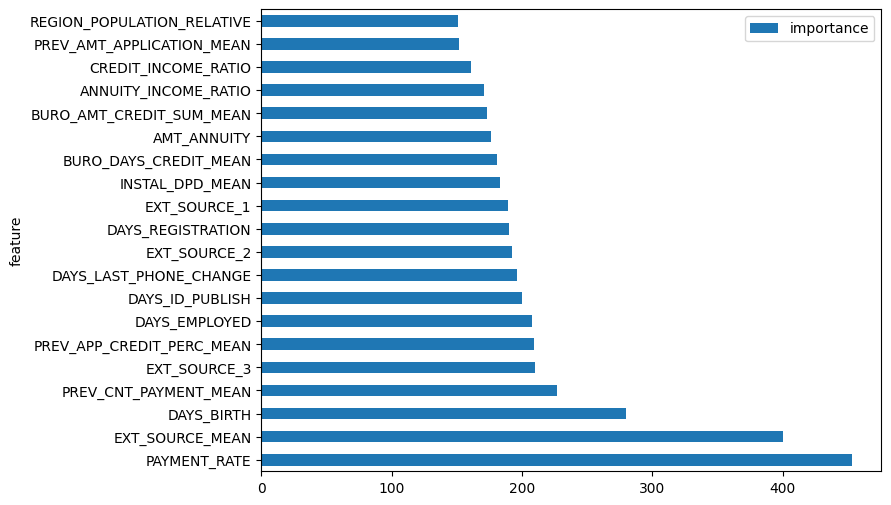

In [43]:
feature_importance_df = global_feature_importance(
    model=BEST_MODEL,
    X=X_clean,
    top_n=20
)

display(feature_importance_df)

#### **4.4.2. Feature importance locale**

In [44]:
# Variables importantes

important_features = (
    feature_importance_df["feature"]
    .head(10)
    .tolist()
)

important_features

['PAYMENT_RATE',
 'EXT_SOURCE_MEAN',
 'DAYS_BIRTH',
 'PREV_CNT_PAYMENT_MEAN',
 'EXT_SOURCE_3',
 'PREV_APP_CREDIT_PERC_MEAN',
 'DAYS_EMPLOYED',
 'DAYS_ID_PUBLISH',
 'DAYS_LAST_PHONE_CHANGE',
 'EXT_SOURCE_2']

Utilisation de SHAP pour : LGBMClassifier


PROFIL : MIN_RISK
Index client : 304671
Probabilité prédite : 0.0007


,feature,value,shap_value,abs_shap
0,EXT_SOURCE_MEAN,0.760221,-1.171158,1.171158
1,AMT_GOODS_PRICE,1350000.0,-0.447192,0.447192
2,NAME_CONTRACT_TYPE_Cash_loans,False,-0.417960,0.417960
3,ELEVATORS_MODE,0.8056,-0.297558,0.297558
4,TOTALAREA_MODE,0.5962,-0.258087,0.258087
5,EXT_SOURCE_2,0.758299,-0.233316,0.233316
6,INSTAL_DPD_MEAN,0.0,-0.183178,0.183178
7,AMT_CREDIT,1350000.0,0.164829,0.164829
8,FLAG_DOCUMENT_3,0,-0.162653,0.162653
9,NAME_EDUCATION_TYPE_Higher_education,True,-0.160694,0.160694


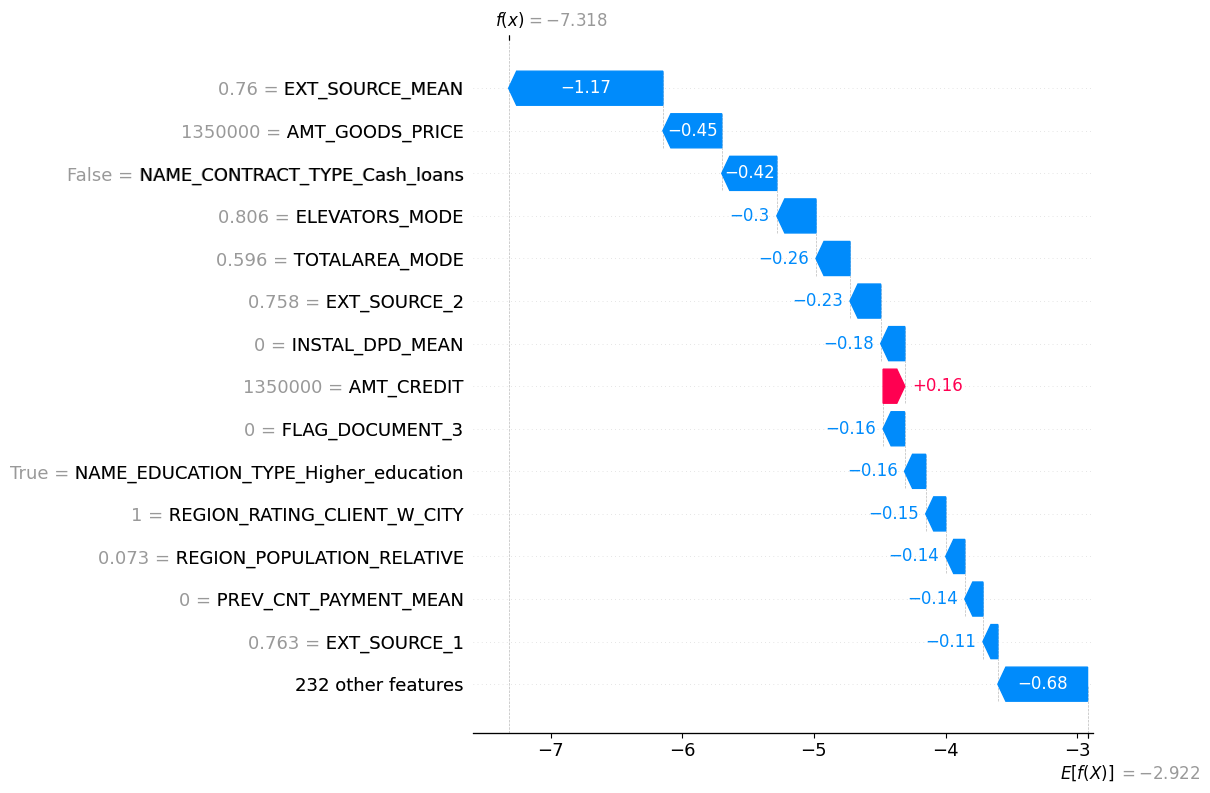



PROFIL : MAX_RISK
Index client : 48554
Probabilité prédite : 0.8279


,feature,value,shap_value,abs_shap
0,EXT_SOURCE_MEAN,0.018566,1.856334,1.856334
1,EXT_SOURCE_3,0.037119,0.625876,0.625876
2,EXT_SOURCE_2,0.000012,0.270804,0.270804
3,BURO_AMT_CREDIT_SUM_DEBT_SUM,2187774.09,0.221327,0.221327
4,OCCUPATION_TYPE_Core_staff,True,-0.185616,0.185616
5,DAYS_ID_PUBLISH,-79,0.175568,0.175568
6,PREV_APP_CREDIT_PERC_MEAN,0.0,0.175101,0.175101
7,PREV_CNT_PAYMENT_MEAN,0.0,-0.166927,0.166927
8,BURO_AMT_CREDIT_SUM_DEBT_MEAN,273471.76125,0.150092,0.150092
9,AMT_GOODS_PRICE,450000.0,0.147547,0.147547


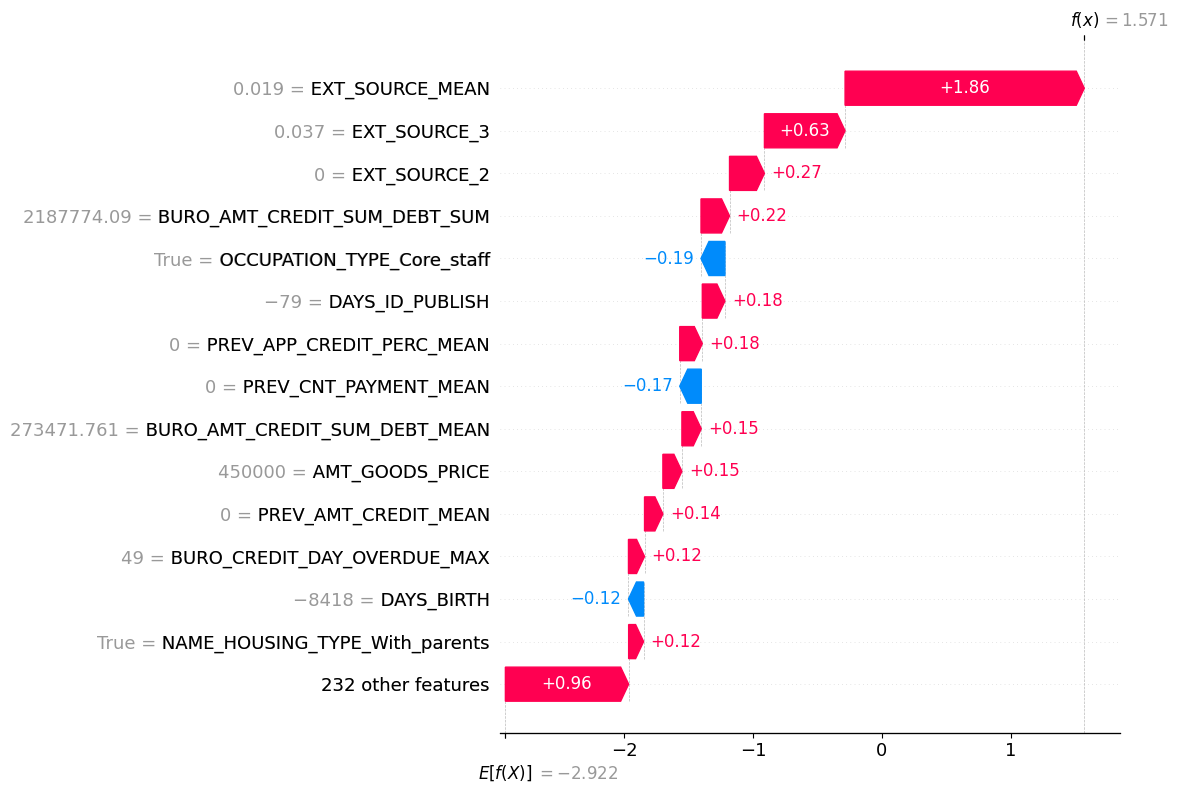



PROFIL : MEAN_RISK
Index client : 62691
Probabilité prédite : 0.0799


,feature,value,shap_value,abs_shap
0,EXT_SOURCE_MEAN,0.457037,0.230799,0.230799
1,AMT_GOODS_PRICE,900000.0,-0.204770,0.204770
2,CODE_GENDER_F,False,0.126941,0.126941
3,BURO_AMT_CREDIT_SUM_DEBT_MEAN,146372.25,0.121963,0.121963
4,FLAG_OWN_CAR_N,False,-0.117757,0.117757
5,INSTAL_DPD_MEAN,0.0,-0.113255,0.113255
6,PREV_CNT_PAYMENT_MEAN,10.5,-0.105697,0.105697
7,BURO_AMT_CREDIT_SUM_DEBT_SUM,878233.5,0.100456,0.100456
8,NAME_FAMILY_STATUS_Married,False,0.084887,0.084887
9,PREV_APP_CREDIT_PERC_MEAN,0.68904,0.082262,0.082262


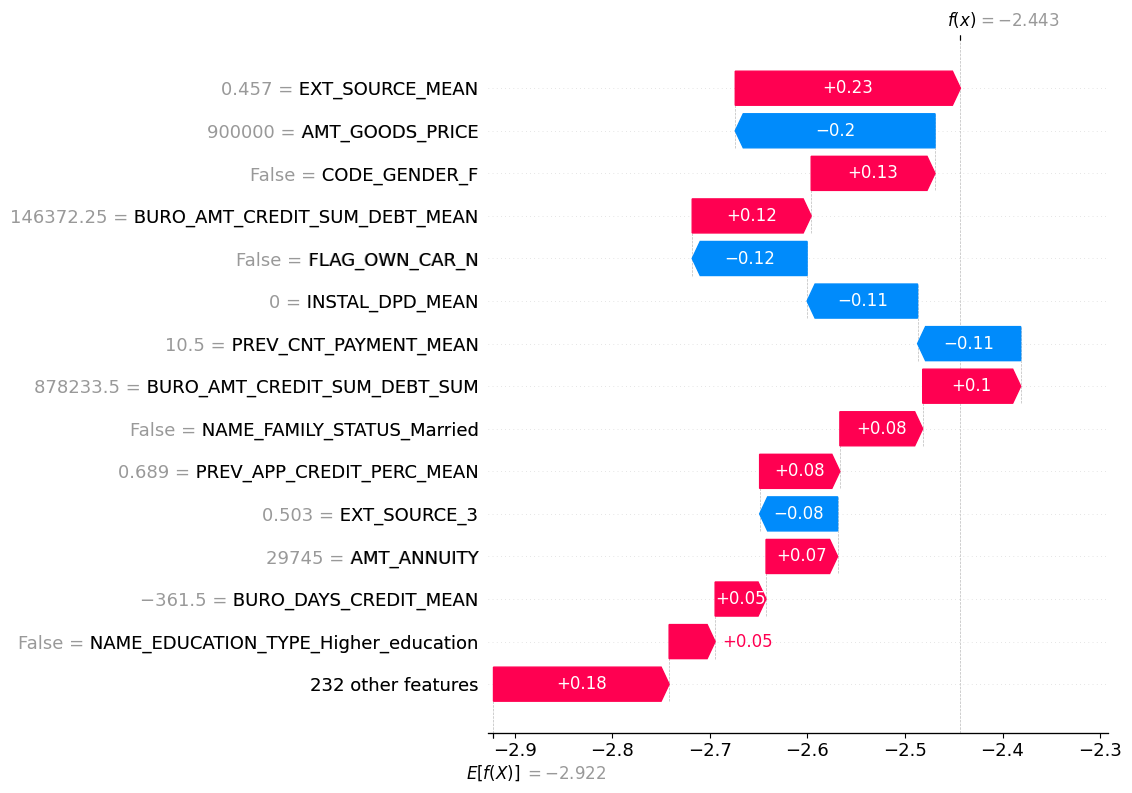



PROFIL : MEDIAN_RISK
Index client : 218982
Probabilité prédite : 0.0485


,feature,value,shap_value,abs_shap
0,INSTAL_DPD_MEAN,3.552632,0.330360,0.330360
1,BURO_AMT_CREDIT_SUM_MEAN,1926861.13125,-0.322800,0.322800
2,CODE_GENDER_F,False,0.184455,0.184455
3,ORGANIZATION_TYPE_Construction,True,0.171274,0.171274
4,PAYMENT_RATE,0.04706,0.153263,0.153263
5,EXT_SOURCE_1,0.307878,-0.135797,0.135797
6,AMT_ANNUITY,13594.5,-0.126777,0.126777
7,EXT_SOURCE_MEAN,0.547583,-0.125792,0.125792
8,PREV_CNT_PAYMENT_MEAN,6.666667,-0.116809,0.116809
9,AMT_GOODS_PRICE,238500.0,0.089018,0.089018


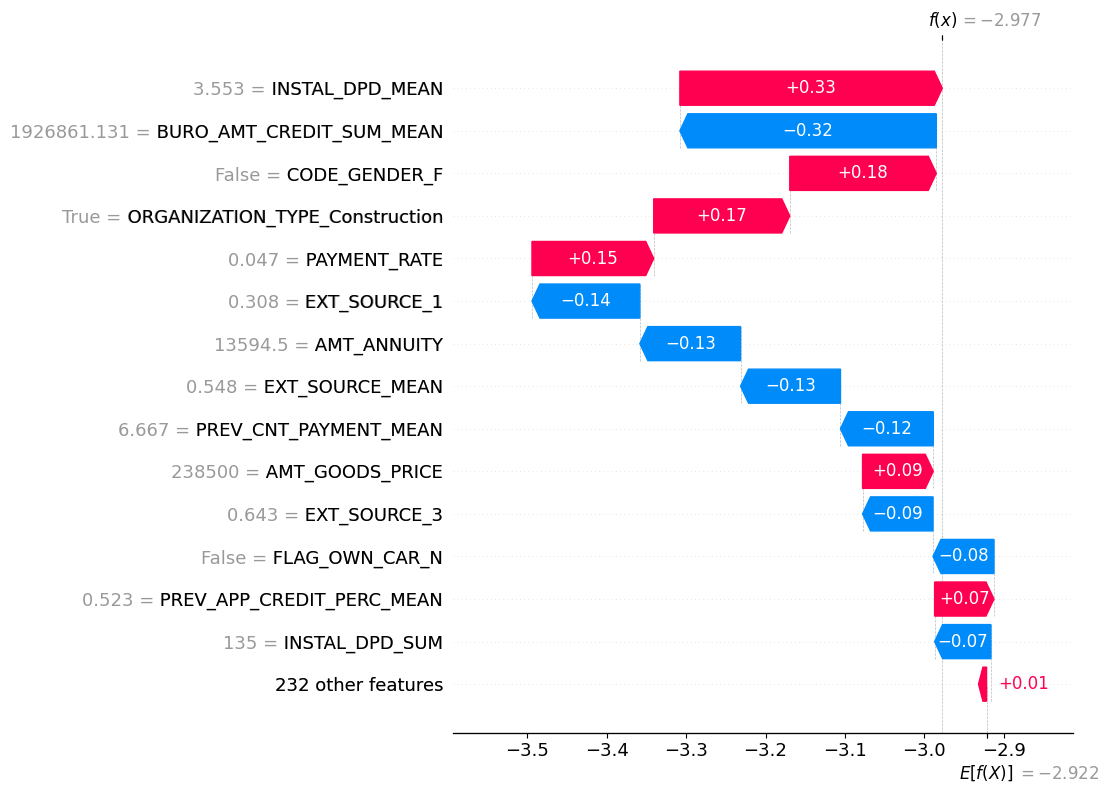



PROFIL : RANDOM_1
Index client : 14343
Probabilité prédite : 0.1104


,feature,value,shap_value,abs_shap
0,AMT_GOODS_PRICE,783000.0,-0.169828,0.169828
1,BURO_AMT_CREDIT_SUM_DEBT_SUM,2223077.715,0.169214,0.169214
2,DAYS_ID_PUBLISH,-331,0.168544,0.168544
3,AMT_CREDIT,1031053.5,0.164016,0.164016
4,CODE_GENDER_F,False,0.155120,0.155120
5,DAYS_EMPLOYED,-476.0,0.142065,0.142065
6,DEF_30_CNT_SOCIAL_CIRCLE,2.0,0.124758,0.124758
7,INSTAL_DPD_MEAN,0.0,-0.115579,0.115579
8,DEF_60_CNT_SOCIAL_CIRCLE,2.0,0.098803,0.098803
9,BURO_AMT_CREDIT_SUM_DEBT_MEAN,317582.530714,0.098566,0.098566


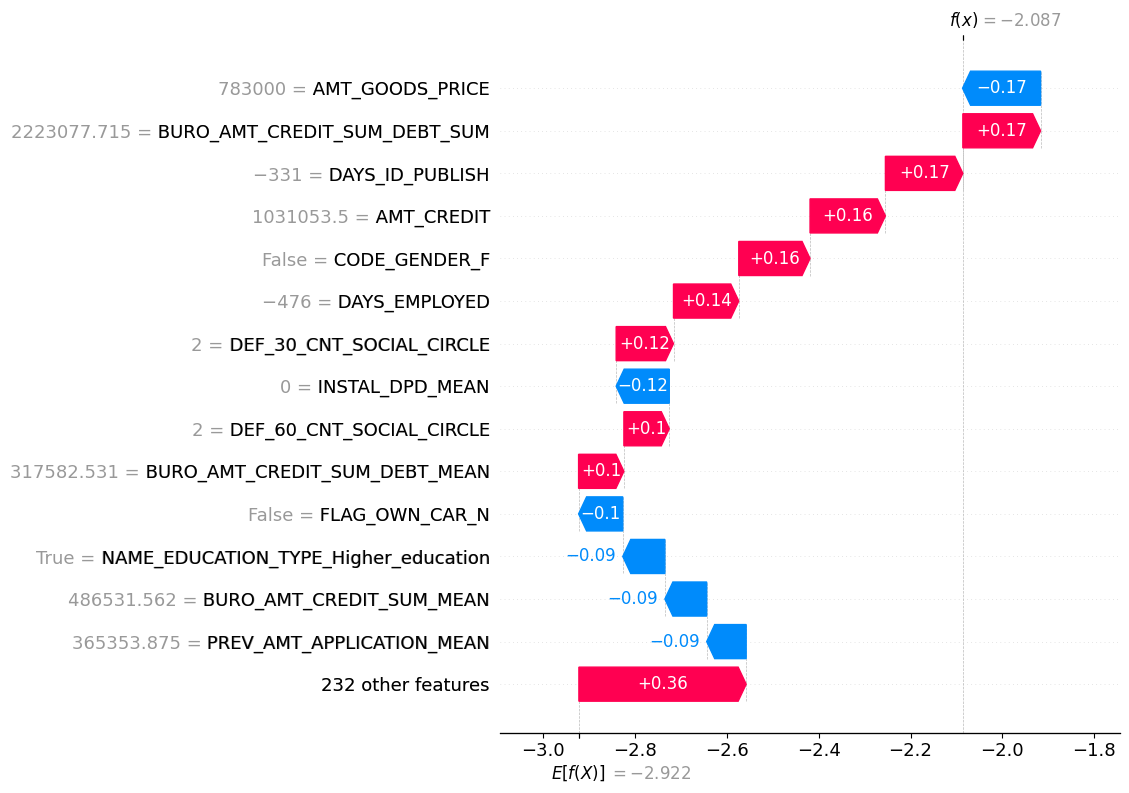



PROFIL : RANDOM_2
Index client : 94529
Probabilité prédite : 0.0550


,feature,value,shap_value,abs_shap
0,PAYMENT_RATE,0.0935,-0.200783,0.200783
1,INSTAL_DPD_MEAN,0.0,-0.191064,0.191064
2,BURO_AMT_CREDIT_SUM_MEAN,0.0,0.182875,0.182875
3,AMT_GOODS_PRICE,450000.0,0.171287,0.171287
4,OCCUPATION_TYPE_Accountants,True,-0.167506,0.167506
5,DAYS_EMPLOYED,-311.0,0.143502,0.143502
6,NAME_EDUCATION_TYPE_Higher_education,True,-0.137427,0.137427
7,PREV_AMT_CREDIT_MEAN,0.0,0.130899,0.130899
8,EXT_SOURCE_1,0.413241,-0.124953,0.124953
9,FLAG_WORK_PHONE,1,0.110229,0.110229


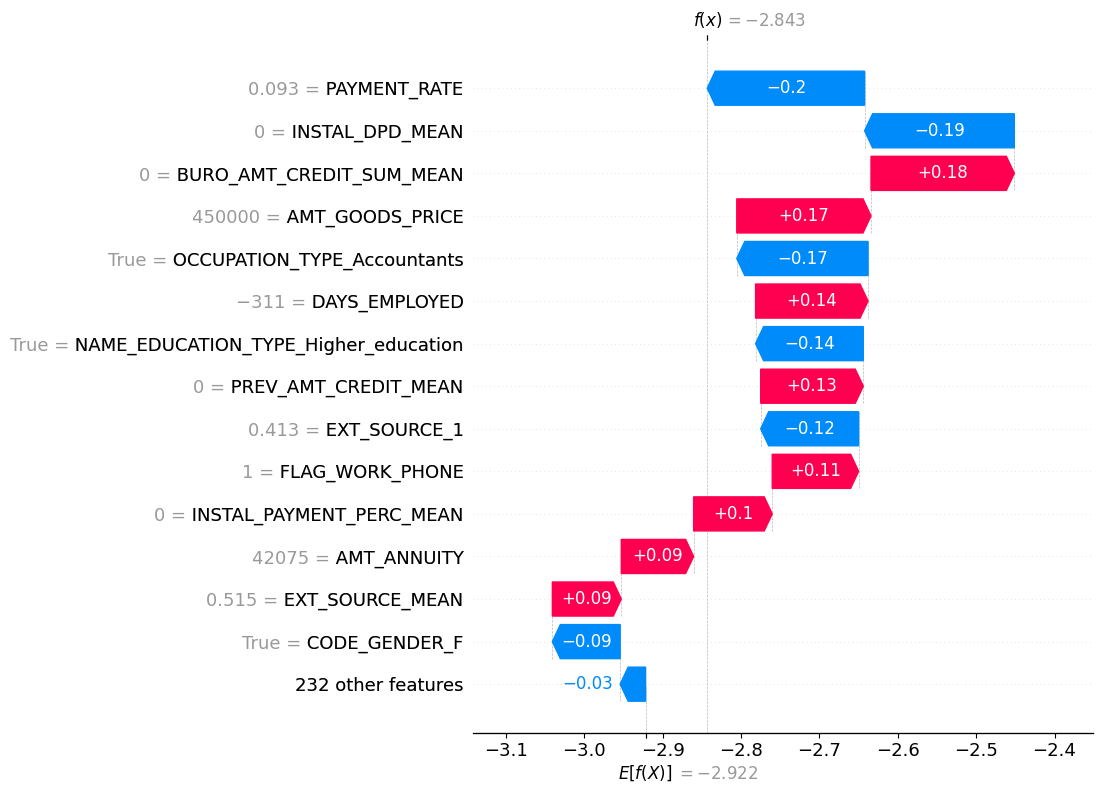



PROFIL : RANDOM_3
Index client : 26833
Probabilité prédite : 0.1262


,feature,value,shap_value,abs_shap
0,EXT_SOURCE_MEAN,0.253703,0.965929,0.965929
1,DAYS_BIRTH,-15038,0.163460,0.163460
2,BURO_AMT_CREDIT_SUM_MEAN,0.0,0.160004,0.160004
3,DAYS_ID_PUBLISH,-5106,-0.147736,0.147736
4,AMT_ANNUITY,13198.5,-0.141069,0.141069
5,AMT_GOODS_PRICE,148500.0,0.135557,0.135557
6,ORGANIZATION_TYPE_Construction,True,0.111604,0.111604
7,INSTAL_DPD_MEAN,0.0,-0.108920,0.108920
8,BURO_AMT_CREDIT_SUM_DEBT_MEAN,0.0,-0.102452,0.102452
9,CODE_GENDER_F,True,-0.097212,0.097212


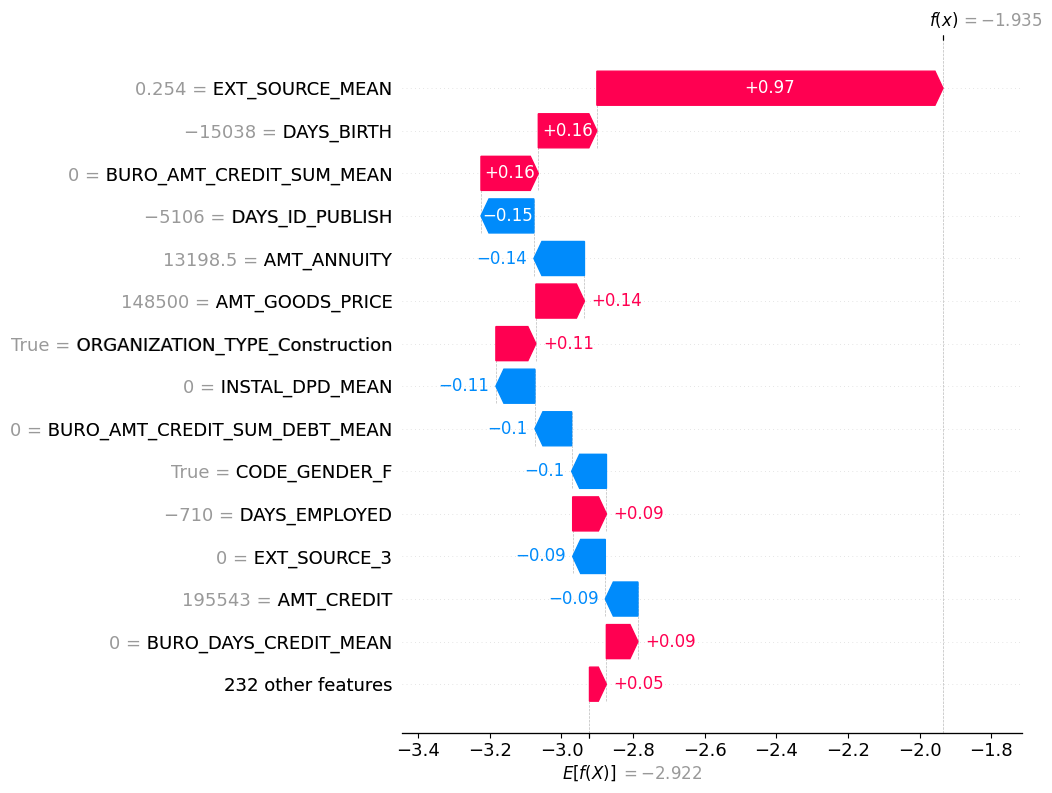

In [ ]:
local_profiles = local_feature_analysis(
    model=BEST_MODEL,
    X=BEST_RESULTS["X_val"],
    y_proba=BEST_RESULTS["y_proba"]
)

#### **4.4.3. Synthèse générale**

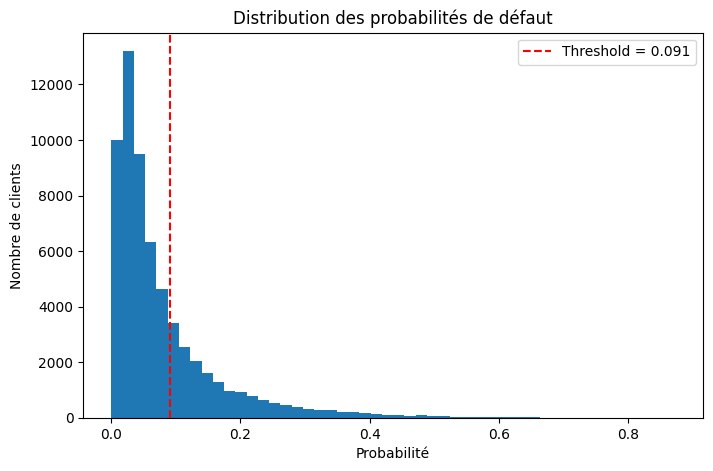


MODÈLE : LGBMClassifier


,metric,value
0,threshold,9.090909e-02
1,business_cost_eur,1.821029e+09
2,business_cost_ratio,4.953150e-02
3,TN,4.265700e+04
4,FP,1.388100e+04
5,FN,1.686000e+03
6,TP,3.279000e+03
7,recall_default,6.604230e-01
8,false_positive_rate,2.455163e-01
9,precision_default,1.910839e-01



FN = 1686 (clients risqués acceptés)
FP = 13881 (clients solvables refusés)
Coût métier estimé = 1,821,029,413 €
Coût métier normalisé = 0.0495


,metric,value
0,threshold,9.090909e-02
1,business_cost_eur,1.821029e+09
2,business_cost_ratio,4.953150e-02
3,TN,4.265700e+04
4,FP,1.388100e+04
5,FN,1.686000e+03
6,TP,3.279000e+03
7,recall_default,6.604230e-01
8,false_positive_rate,2.455163e-01
9,precision_default,1.910839e-01


In [45]:
global_metrics = global_model_analysis(
    y_val=BEST_RESULTS["y_val"],
    y_proba=BEST_RESULTS["y_proba"],
    loan_amount=BEST_RESULTS["loan_amount"],
    threshold=BEST_RESULTS["threshold"],
    model_name=BEST_MODEL_NAME
)

display(global_metrics)

##### **Synthèse du modèle retenu**

Le modèle finalement retenu est un **LightGBM Classifier** optimisé à l'aide d'une validation croisée (*GridSearchCV*) et d'une recherche d'hyperparamètres.

Les performances obtenues sur l'échantillon de validation sont les suivantes :

* **AUC : 0.777**
* **Coût métier estimé : 1 821 029 413 €**
* **Coût métier normalisé : 0.0495**
* **Seuil métier optimal : 0.0909**

L'optimisation du seuil a été réalisée à partir d'une fonction de coût métier intégrant :

* les montants réels des crédits (`AMT_CREDIT`) ;
* les probabilités de défaut prédites ;
* une pondération métier accordant un coût dix fois plus élevé aux faux négatifs qu'aux faux positifs.

Cette stratégie vise à limiter l'acceptation de clients susceptibles de faire défaut, même si elle conduit à accepter davantage de faux positifs.

Les résultats obtenus au seuil optimal sont les suivants :

* **TP : 3 279**
* **TN : 42 657**
* **FP : 13 881**
* **FN : 1 686**
* **Recall défaut : 66.0 %**
* **Accuracy : 74.7 %**

Le modèle détecte ainsi près de deux tiers des clients en défaut tout en maintenant un coût métier inférieur à celui observé avec les modèles de référence.

##### **Principaux facteurs de risque identifiés**

L'analyse globale des importances de variables montre que les facteurs les plus influents sont principalement :

* `PAYMENT_RATE`
* `EXT_SOURCE_MEAN`
* `DAYS_BIRTH`
* `PREV_CNT_PAYMENT_MEAN`
* `EXT_SOURCE_3`
* `PREV_APP_CREDIT_PERC_MEAN`
* `DAYS_EMPLOYED`
* `DAYS_ID_PUBLISH`
* `DAYS_LAST_PHONE_CHANGE`
* `EXT_SOURCE_2`

Plus globalement, les variables les plus contributives proviennent de plusieurs familles :

* les scores externes (`EXT_SOURCE_*`) ;
* les ratios financiers (`PAYMENT_RATE`, `ANNUITY_INCOME_RATIO`, `CREDIT_INCOME_RATIO`) ;
* les variables démographiques ;
* les historiques de crédit (`BURO_*`) ;
* les historiques de remboursement (`INSTAL_*`) ;
* les informations issues des demandes précédentes (`PREV_*`).

##### **Apport des analyses locales**

L'utilisation de SHAP permet d'interpréter les prédictions individuelles du modèle.

Les analyses réalisées mettent notamment en évidence que :

* les profils les moins risqués présentent généralement des valeurs élevées des variables `EXT_SOURCE`, peu de retards de paiement et des caractéristiques financières favorables ;
* les profils les plus risqués présentent des scores externes faibles, un endettement plus important et des historiques de remboursement moins favorables ;
* les variables liées aux comportements passés de crédit et de remboursement jouent un rôle déterminant dans la construction du score de risque.

Cette approche améliore la transparence du modèle et facilite la justification des décisions de crédit auprès des utilisateurs métier.

##### **Conclusion**

Le modèle **LightGBMClassifier** constitue la meilleure solution parmi les approches évaluées.

Les travaux réalisés ont permis :

* de construire un dataset enrichi à partir de plusieurs sources de données ;
* de développer un pipeline complet de feature engineering ;
* d'intégrer des variables comportementales issues des historiques clients ;
* d'optimiser les hyperparamètres du modèle ;
* de mettre en place une métrique de coût métier tenant compte de l'exposition financière réelle ;
* d'identifier un seuil de décision optimisé pour le contexte métier étudié.

Le modèle retenu sera déployé sous forme d'une API permettant de calculer la probabilité de défaut d'un client ainsi que la décision d'acceptation ou de refus basée sur le seuil métier optimal identifié lors de la phase de modélisation.